# Progress Report

### Setup

In [1]:
# Imports
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import os




import matplotlib
print(matplotlib.get_backend())
#%matplotlib inline
#import matplotlib
#matplotlib.use("TkAgg")     #for smoother plotting


# From own module import file parser function pandaizer
from parser_pandaizer import *

module://matplotlib_inline.backend_inline


In [2]:
# Patterns
patterns = ["7143", "23296", "30012"]

# Main results directory
resultsdir = "../../Results/"
savedir = "../../Results/Figures/"

### Parse data

#### First test

done
done
done
done
done
done
done
done
done


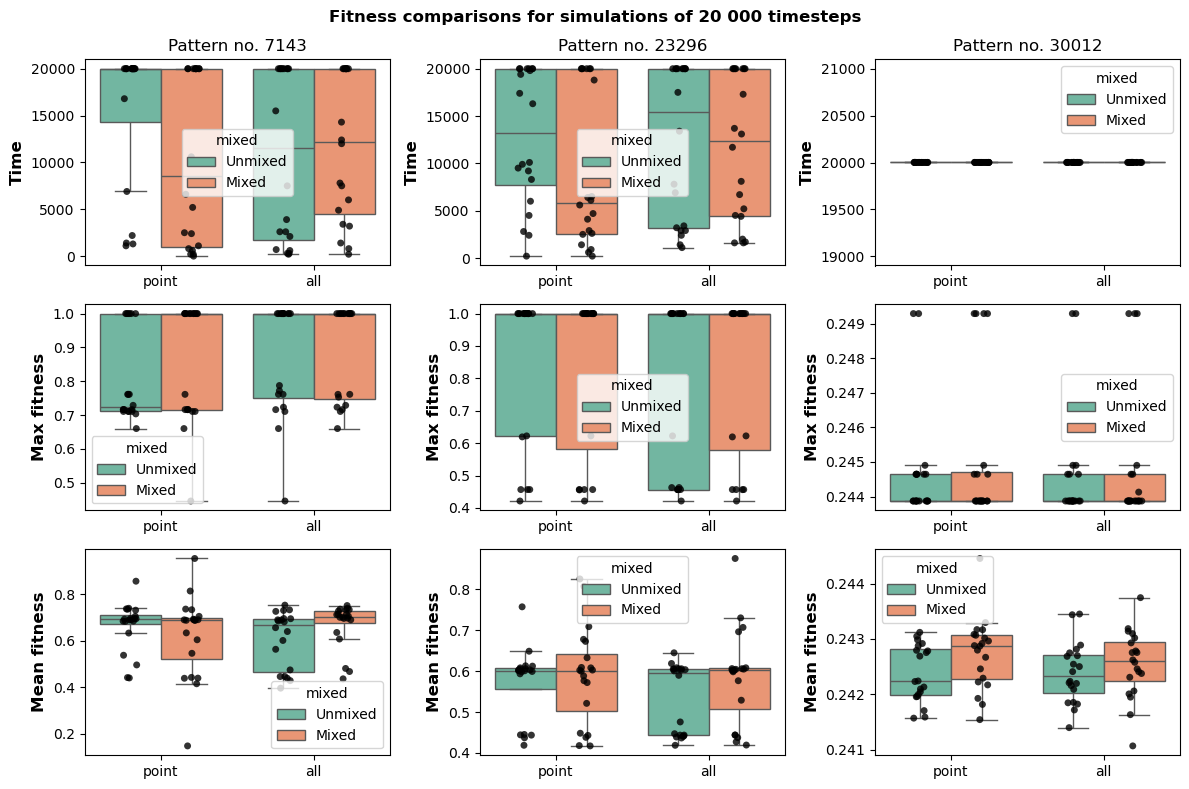

In [3]:
data_first = empty() #using empty from parser_pandaizer



for pattern in patterns:
    for mut in ["point", "all"]:
        for mix in ["", "_mixed"]:
            data_first = concatenator(data_first, pandaizer (resultsdir + "First_test/" + mut + "_t" + pattern + "_s0" + mix + ".log",
                                                pattern, mut = mut, mixed = mix == "_mixed"))
   
fig, axes = plt.subplots(3, 3, figsize = (12, 8))

metrics = ["time", "maxF", "meanF"]
titles = ["Time", "Max fitness", "Mean fitness"]

for i in range(3):    
    for ax, metric, title in zip(axes.T[i], metrics, titles):
        ax = sns.boxplot(
            data=data_first[data_first["target"] == patterns[i]],
            x="mutations",
            y=metric,
            hue="mixed",
            ax=ax,
            palette="Set2",
            fliersize = 0
        )
        ax = sns.stripplot(
            data=data_first[data_first["target"] == patterns[i]],
            x="mutations",
            y=metric,
            hue="mixed",
            ax=ax,
            palette=["000", "000"],
            #color = "b",
            dodge=True,
            alpha=0.8,
            size=5,
            legend=False
        )
        ax.set_xlabel("", fontsize=12, fontweight="bold")
        ax.set_ylabel(title, fontsize=12, fontweight="bold")
        #ax.set_title(title, fontsize=13, fontweight="bold")
        print("done")
    axes[0][i].set_title("Pattern no. " + patterns[i])
plt.suptitle("Fitness comparisons for simulations of 20 000 timesteps", fontweight="bold")
plt.tight_layout()
plt.savefig(savedir + "fitness_comparisons_t20k_ss1_default_mut.png")
#fig.bbox_inches = "tight"
plt.show()


#### Second test

This simulation has the same data values as the first one, so it seems like I messed up and these results can be ignored

done
done
done
done
done
done


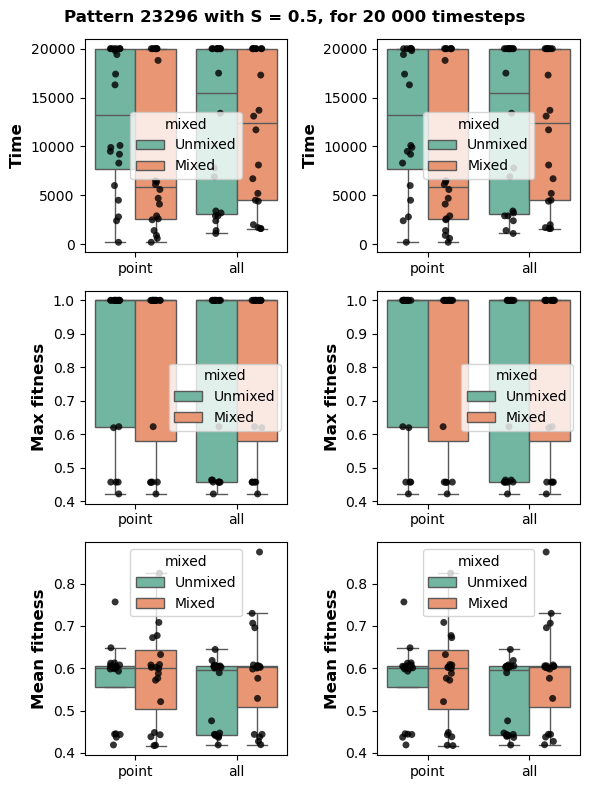

In [4]:
data_second = empty()

for mut in ["point", "all"]:
        for mix in ["", "_mixed"]:
            data_second = concatenator(data_second,
                                       pandaizer (resultsdir + "First_test/" + mut + "_t" + "23296" + "_s0" + mix + ".log",
                                                  "23296", mut = mut,
                                                  mixed = mix == "_mixed", sel_str = 0.5))

fig, axes = plt.subplots (3, 2, figsize=(6, 8))

metrics = ["time", "maxF", "meanF"]
titles = ["Time", "Max fitness", "Mean fitness"]
slice = data_first[data_first["target"] == "23296"]
datasets = [slice, data_second]
for i in range(2):
    for ax, metric, title in zip(axes.T[i], metrics, titles):
            ax = sns.boxplot(
                data=datasets[i],
                x="mutations",
                y=metric,
                hue="mixed",
                ax=ax,
                palette="Set2",
                fliersize = 0
            )
            ax = sns.stripplot(
                data=datasets[i],
                x="mutations",
                y=metric,
                hue="mixed",
                ax=ax,
                palette=["000", "000"],
                #color = "b",
                dodge=True,
                alpha=0.8,
                size=5,
                legend=False
            )
            ax.set_xlabel("", fontsize=12, fontweight="bold")
            ax.set_ylabel(title, fontsize=12, fontweight="bold")
            #ax.set_title(title, fontsize=13, fontweight="bold")
            print("done")
    
plt.suptitle("Pattern 23296 with S = 0.5, for 20 000 timesteps", fontweight="bold")
plt.tight_layout()
plt.savefig(savedir + "fitness_comparisons_t20k_ss0.5_default_mut.png")
#fig.bbox_inches = "tight"
plt.show()

del data_second, data_first

#### Third experiment - 100k timesteps

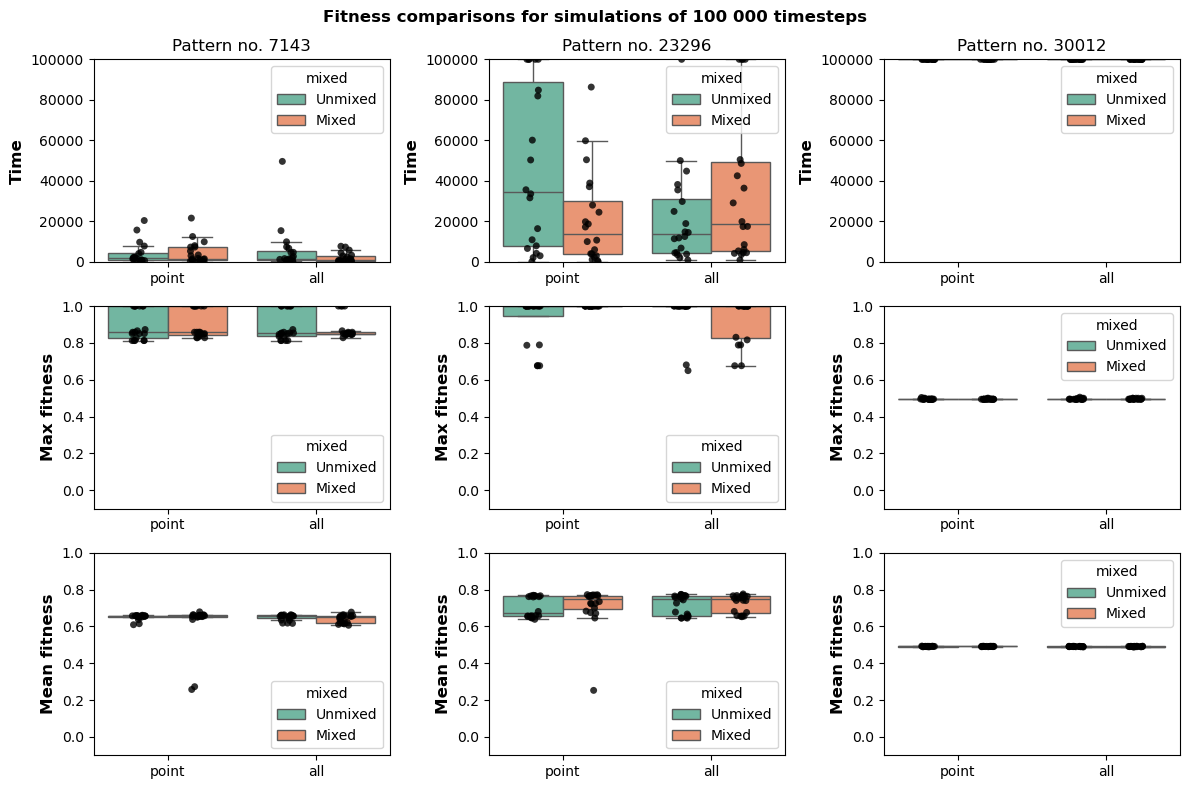

In [5]:
data_third = empty()
for pattern in patterns:
    for mut in ["point", "all"]:
        for mix in ["", "_mixed"]:
            data_third = concatenator(data_third, pandaizer (resultsdir + "Third_test_100k/" + mut + "_t" + pattern + "_s0" + mix + ".log",
                                                pattern, mut = mut, mixed = mix == "_mixed"))
            
fig, axes = plt.subplots(3, 3, figsize = (12, 8))

metrics = ["time", "maxF", "meanF"]
titles = ["Time", "Max fitness", "Mean fitness"]

for i in range(3):    
    for ax, metric, title in zip(axes.T[i], metrics, titles):
        ax = sns.boxplot(
            data=data_third[data_third["target"] == patterns[i]],
            x="mutations",
            y=metric,
            hue="mixed",
            ax=ax,
            palette="Set2",
            fliersize = 0
        )
        ax = sns.stripplot(
            data=data_third[data_third["target"] == patterns[i]],
            x="mutations",
            y=metric,
            hue="mixed",
            ax=ax,
            palette=["000", "000"],
            dodge=True,
            alpha=0.8,
            size=5,
            legend=False
        )
        ax.set_xlabel("", fontsize=12, fontweight="bold")
        ax.set_ylabel(title, fontsize=12, fontweight="bold")

        if metric == "time":
            ax.set_ylim(0, 100000)
        else:
            ax.set_ylim(-0.1, 1)
        
    axes[0][i].set_title("Pattern no. " + patterns[i])
plt.suptitle("Fitness comparisons for simulations of 100 000 timesteps", fontweight="bold")
plt.tight_layout()
plt.savefig(savedir + "fitness_comparisons_t100k_ss1_default_mut.png")
plt.show()

del data_third

#### Helper functions for reading and plotting

In [6]:
def readerloop (subdir, patterns, data, sel_str_values = [round(0.1 * i, 1) for i in range(1, 11)],
                simtime=20000, gridsize="50x50"):
    for pattern in patterns:
        for mut in ["point", "all"]:
            for mix in ["", "_mixed"]:
                for ss in sel_str_values:
                    data = concatenator(data, pandaizer (resultsdir + subdir + mut + "_t" + pattern + "_s0" + "_ss" + str(ss) + mix + ".log",
                                                         pattern, mut = mut,
                                                         sel_str=ss,
                                                         mixed = mix == "_mixed",
                                                         gridsize=gridsize))
    
    return data

def simple_plotter_box (axis, data,  x, y, hue="mixed"):
    axis = sns.boxplot(
        data=data,
        x=x,
        y=y,
        hue="mixed",
        ax=axis,
        palette="Set2",
        fliersize = 0
    )
    axis = sns.stripplot(
        data=data,
        x=x,
        y=y,
        hue="mixed",
        ax=axis,
        palette=["000", "000"],
        dodge=True,
        alpha=0.8,
        size=5,
        legend=False
    )

def simple_plotter_violin (axis, data,  x, y, hue="mixed"):
    axis = sns.violinplot(
        data=data,
        x=x,
        y=y,
        hue="mixed",
        ax=axis,
        palette="Set2",
    )
    axis = sns.stripplot(
        data=data,
        x=x,
        y=y,
        hue="mixed",
        ax=axis,
        palette=["000", "000"],
        dodge=True,
        alpha=0.8,
        size=5,
        legend=False
    )

In [17]:
def metaplotter (data, savepath = None, mode="fitness", plottype="box", suptitle=""):
    
    if mode == "fitness":
        metrics = ["time", "maxF", "meanF"]
        titles = ["Time", "Max fitness", "Mean fitness"]
    elif mode == "distance":
        metrics = ["time", "least_distance", "mean_distance"]
        titles = ["Time", "Least distance", "Mean distance"]
    
    fig, axes = plt.subplots(3, 2, figsize=(18, 10))
    
    for i, mut in enumerate(["point", "all"]):    
        for ax, metric, title in zip(axes.T[i], metrics, titles):
            
            if plottype == "box":
                simple_plotter_box(ax, data[data["mutations"] == mut], x="sel_str", y=metric)
            elif plottype == "violin":
                simple_plotter_violin(ax, data[data["mutations"] == mut], x="sel_str", y=metric)
            
            ax.set_xlabel("", fontsize=12, fontweight="bold")
            if i == 0:
                ax.set_ylabel(title, fontsize=12, fontweight="bold")
            else:
                ax.set_ylabel("")
            if metric != "time":
                ax.set_ylim(-0.1, 1)

            ax.legend(title=None, edgecolor=None)
        axes[0][i].set_title("Mutations: " + mut)

        
    plt.suptitle(suptitle, fontweight="bold")
    plt.tight_layout()
    
    if savepath != None:
        plt.savefig(savepath)
        
    plt.show()
    

In [8]:
def distance_calculator (data):
    data["mean_distance"] = np.where(data["meanF"] == 1, 0, 1 - ( ( data["meanF"] ** ( 1 / data["sel_str"] )) / 0.8 ) )
    data["least_distance"] = np.where(data["maxF"] == 1, 0, 1 - ( ( data["maxF"] ** ( 1 / data["sel_str"] )) / 0.8 ) )

#### Fourth test - selection parameter sweep

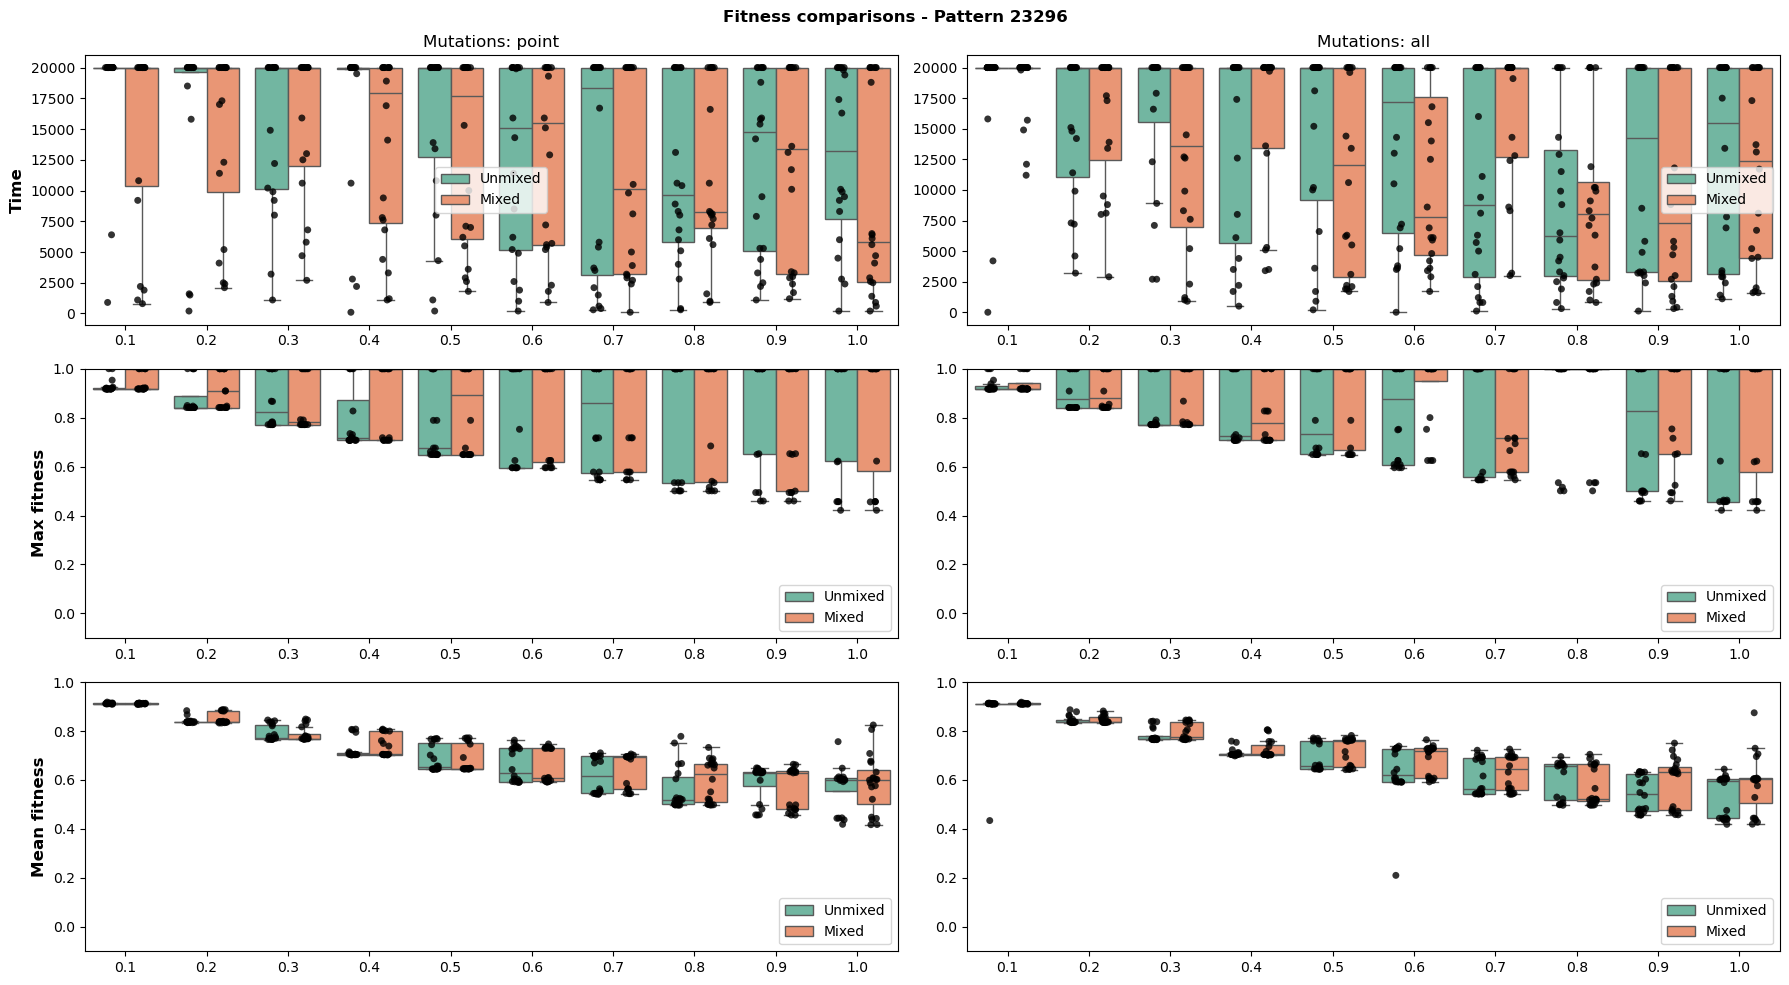

In [18]:
data_fourth = empty()

data_fourth = readerloop("Fourth_test/", ["23296"], data_fourth)

metaplotter(data_fourth, savepath = savedir + "fitness_comparisons_t20k_ss0.1-1_default_mut.png",
           suptitle = "Fitness comparisons - Pattern 23296")


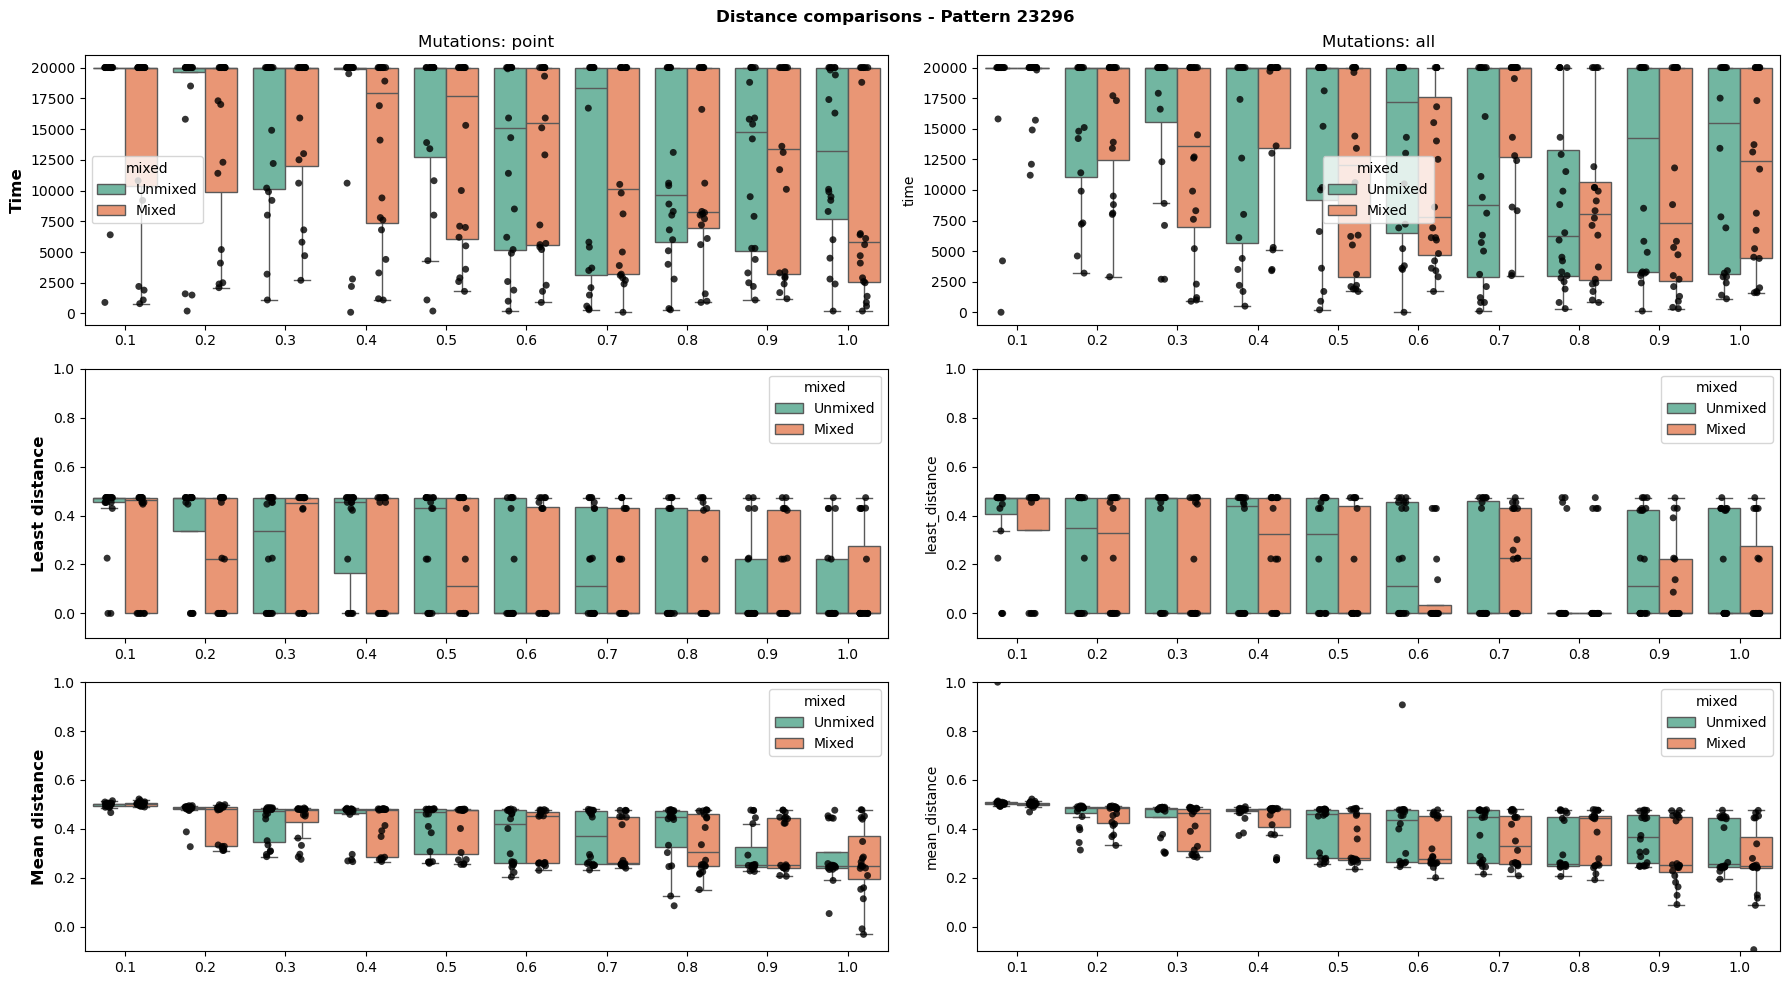

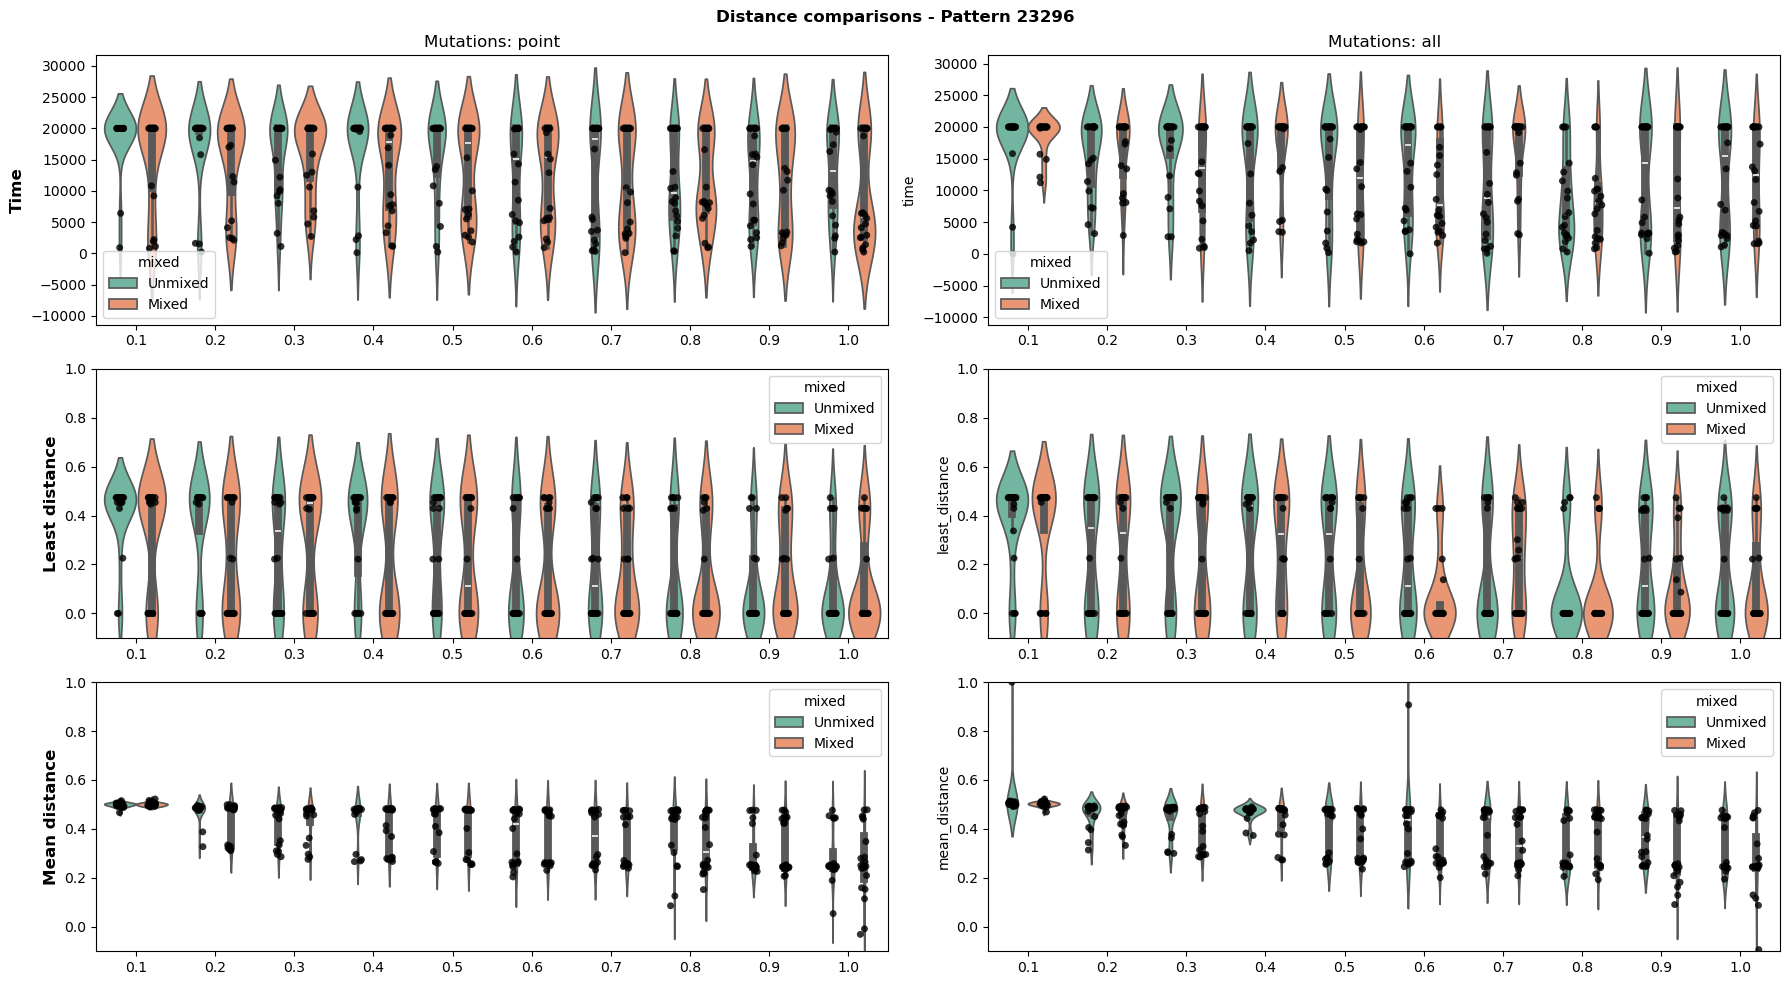

In [10]:
distance_calculator(data_fourth)

metaplotter(data_fourth, mode="distance", plottype="box",
           savepath = savedir + "distance_comparisons_box_t20k_ss0.1-1_default_mut.png",
           suptitle = "Distance comparisons - Pattern 23296")

metaplotter(data_fourth, mode="distance", plottype="violin",
           savepath = savedir + "distance_comparisons_violin_t20k_ss0.1-1_default_mut.png",
           suptitle = "Distance comparisons - Pattern 23296")

#### Fifth test - 10x lower mutation rates

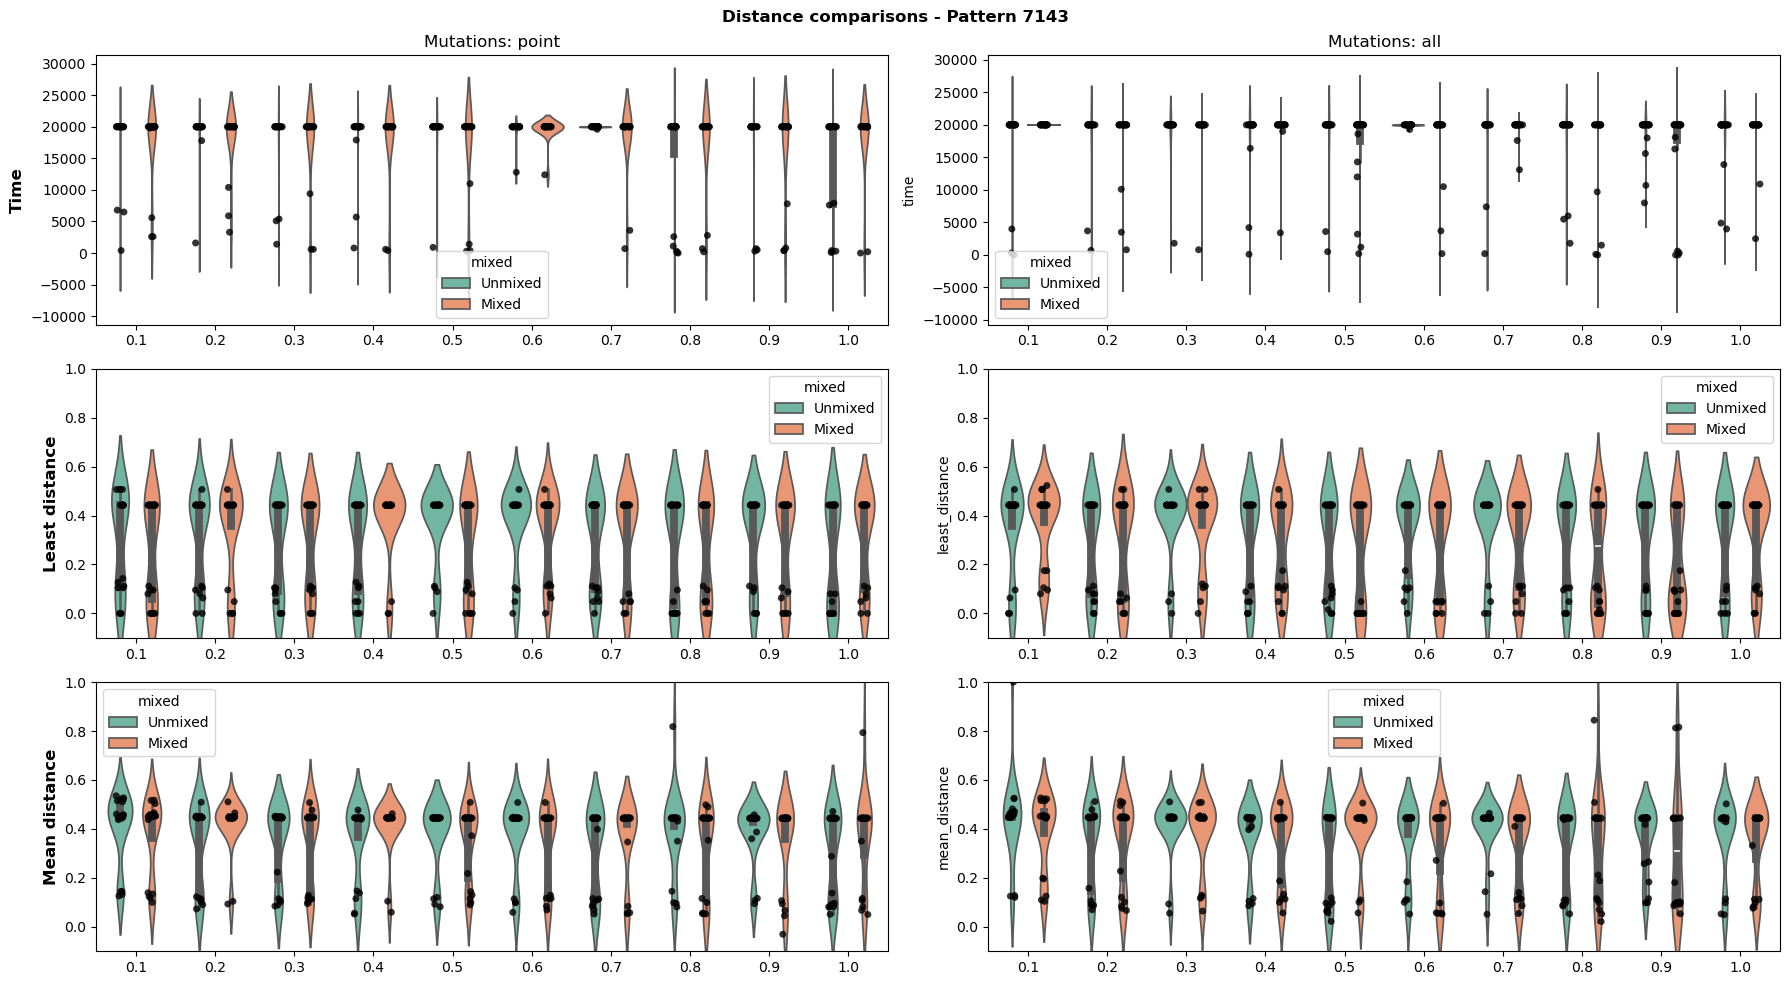

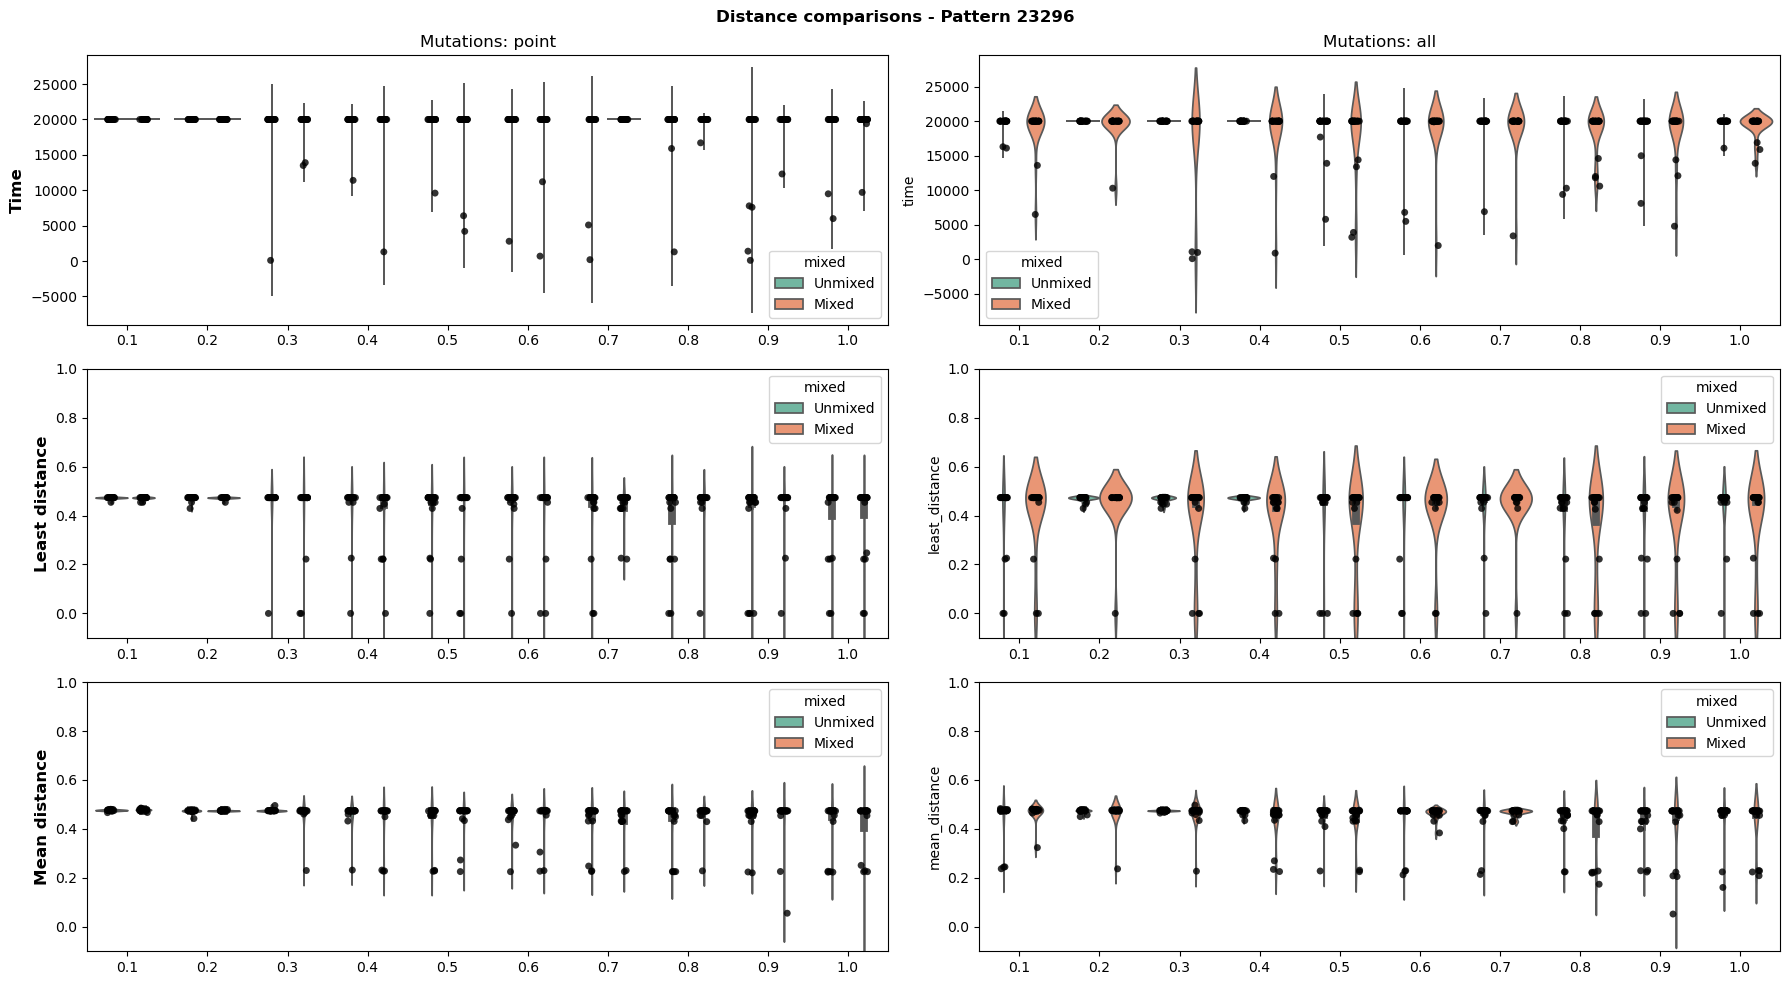

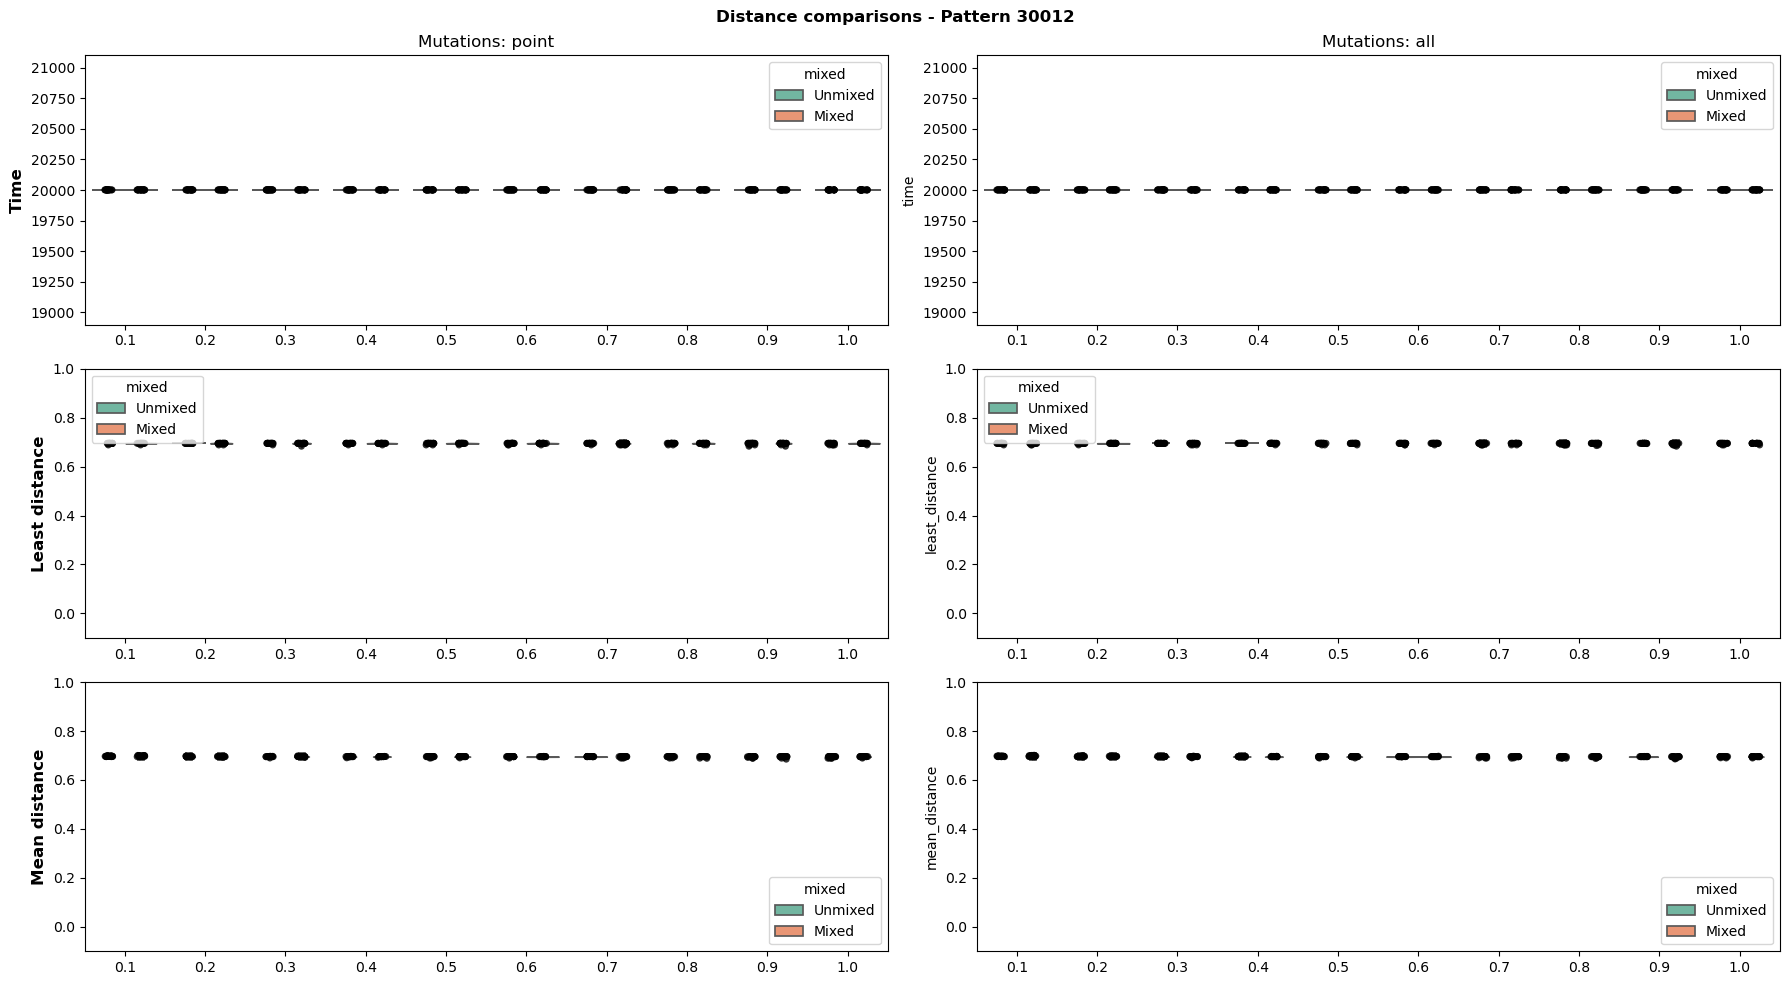

In [11]:
data_fifth = empty()
data_fifth = readerloop("Fifth_test/", patterns, data_fifth)
distance_calculator(data_fifth)

for p in patterns:
    metaplotter(data_fifth[data_fifth["target"] == p], mode = "distance", plottype="violin",
               suptitle = "Distance comparisons - Pattern " + p,
               savepath = savedir + "distance_comparisons_p" + p + "_t20k_ss0.1-1_10xlower_all_rates.png")

#### Sixth test - 10x lower point rates

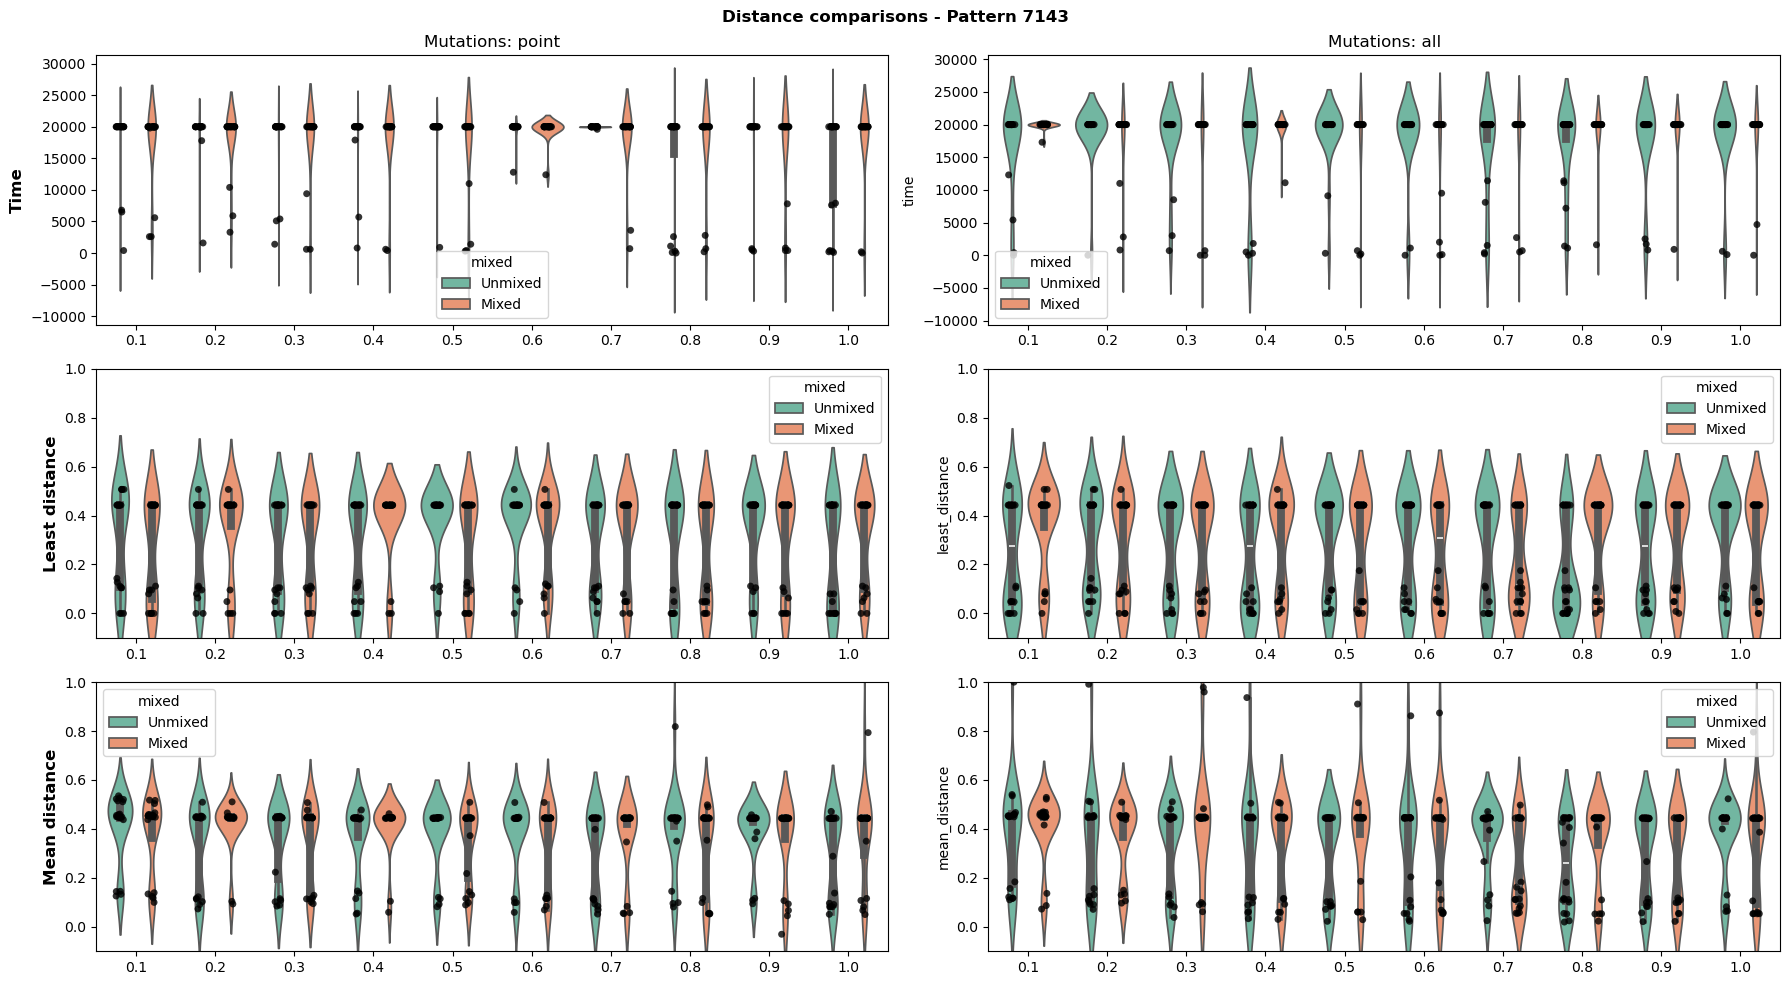

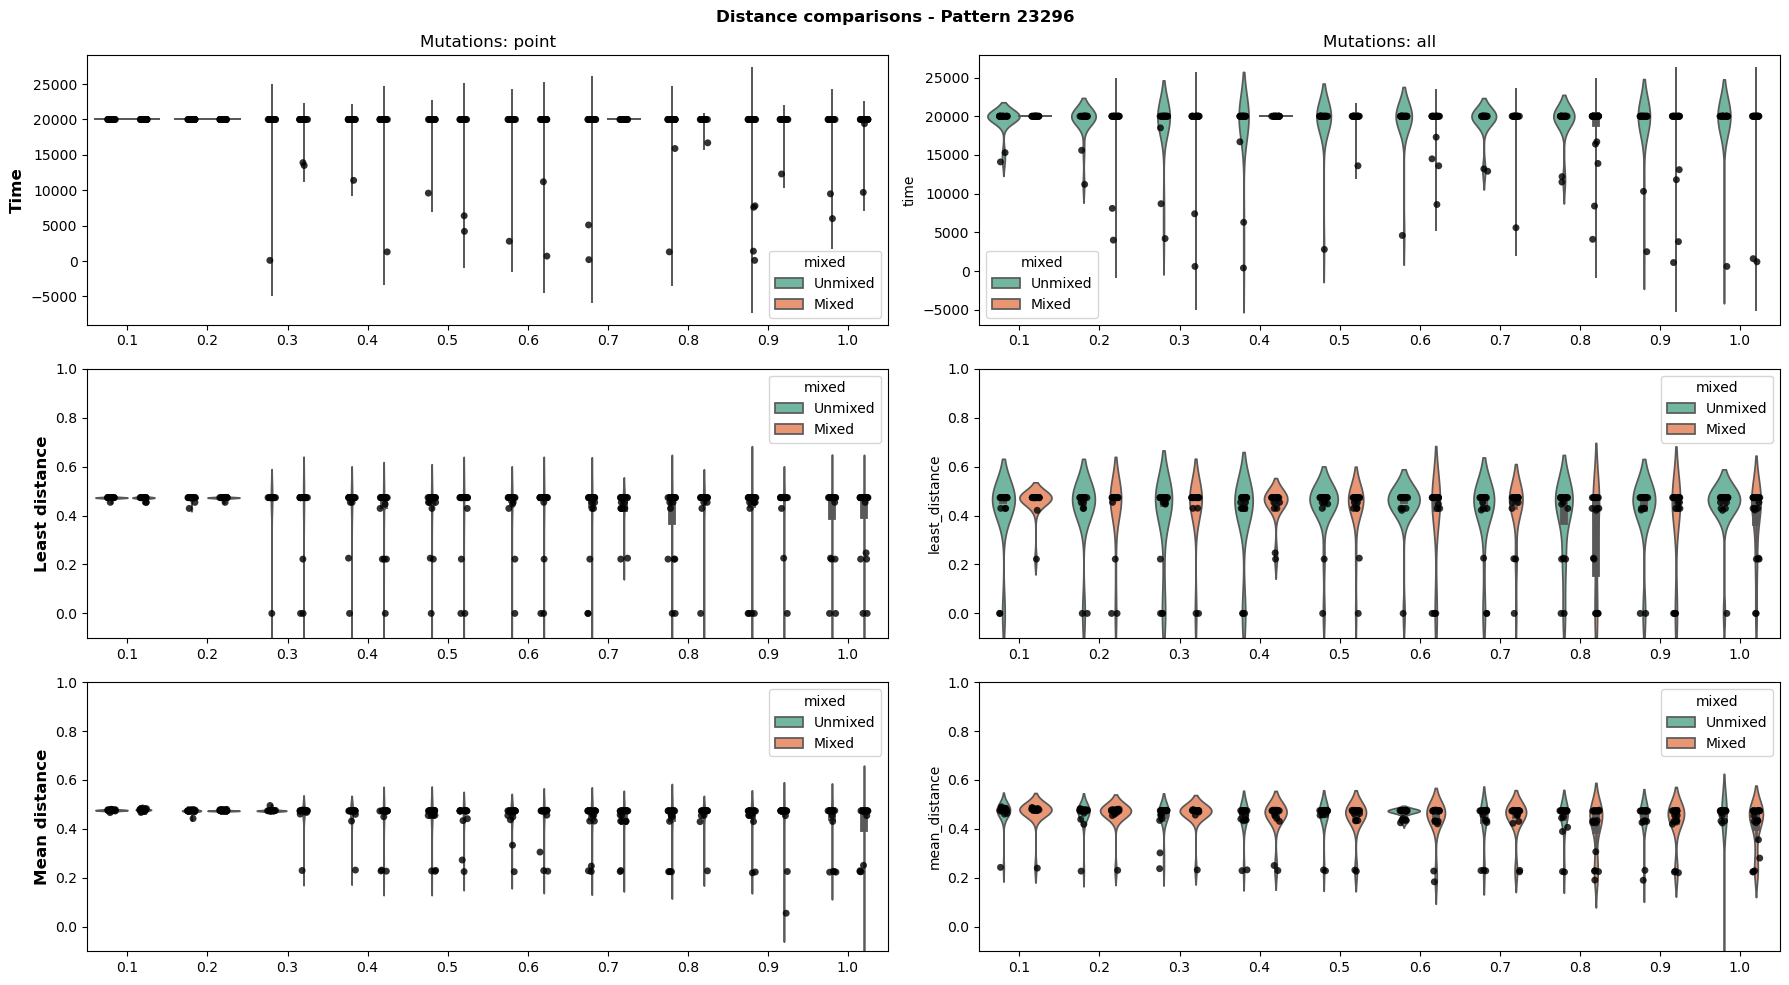

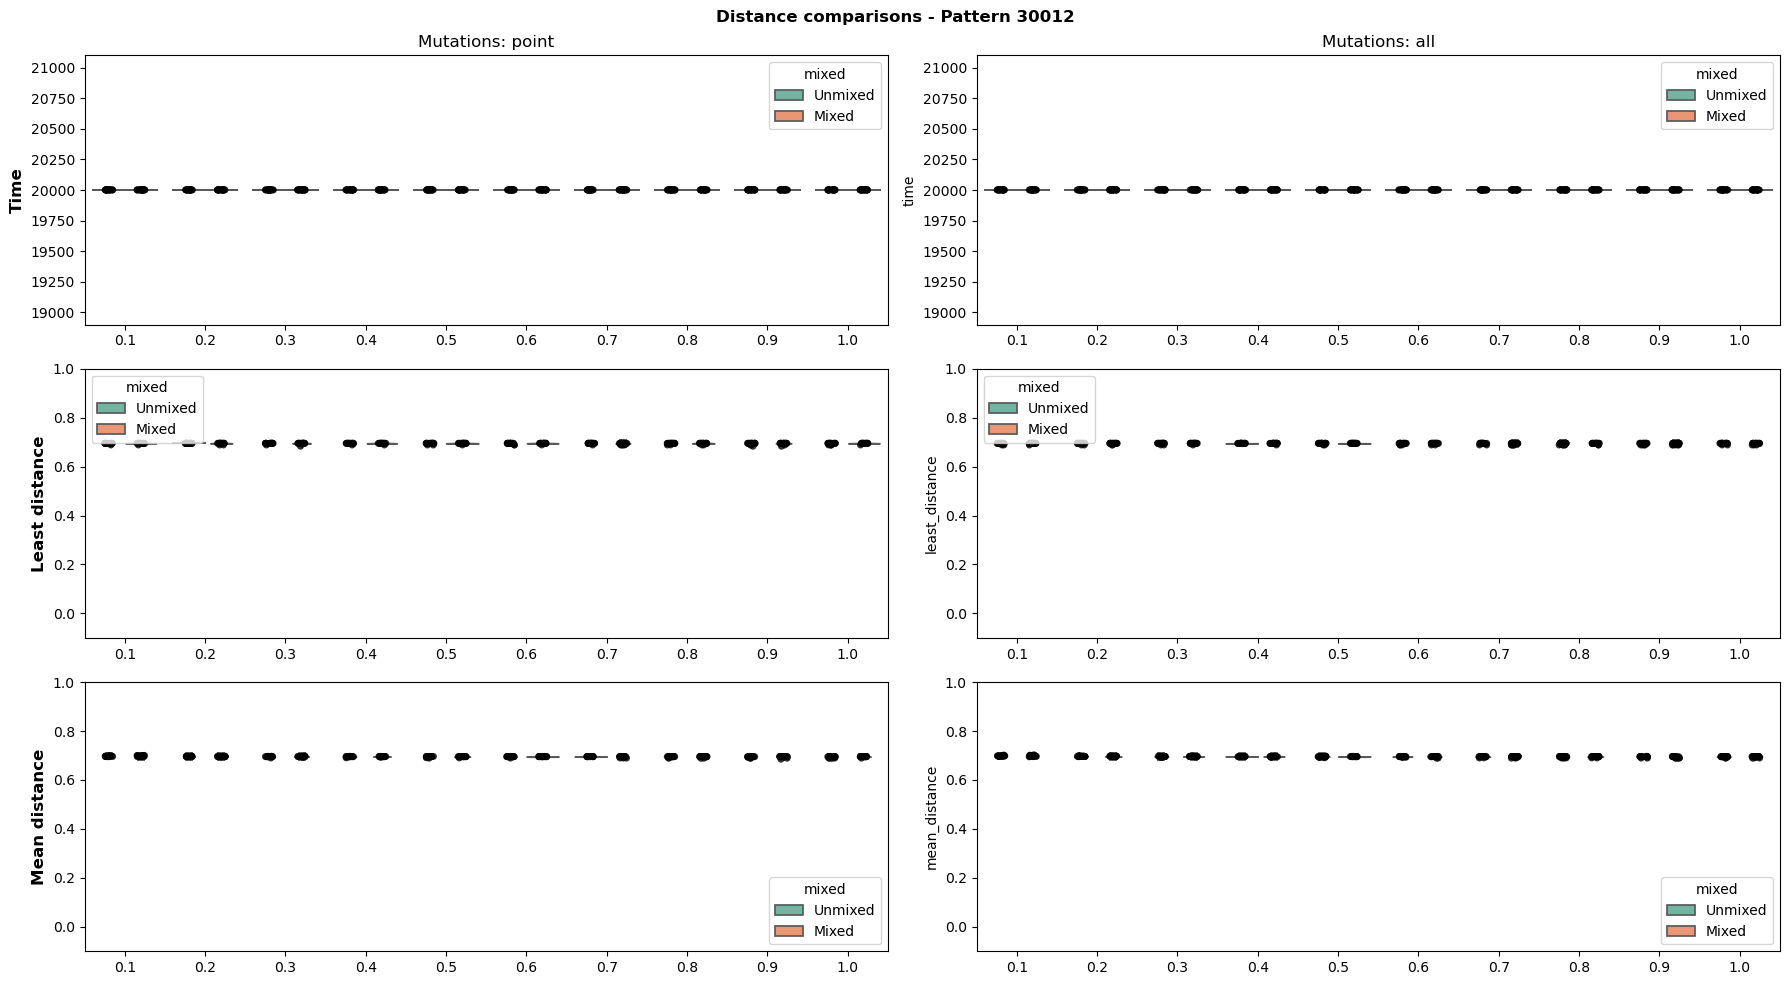

In [12]:
data_sixth = empty()
data_sixth = readerloop("Sixth_test_10x_lower_point_50x50/", patterns, data_sixth)
distance_calculator(data_sixth)

for p in patterns:
    metaplotter(data_sixth[data_sixth["target"] == p], mode = "distance", plottype="violin",
               suptitle = "Distance comparisons - Pattern " + p,
               savepath = savedir + "distance_comparisons_p" + p + "_t20k_ss0.1-1_10xlower_point_rates.png")

#### Seventh test - 25x100 grid

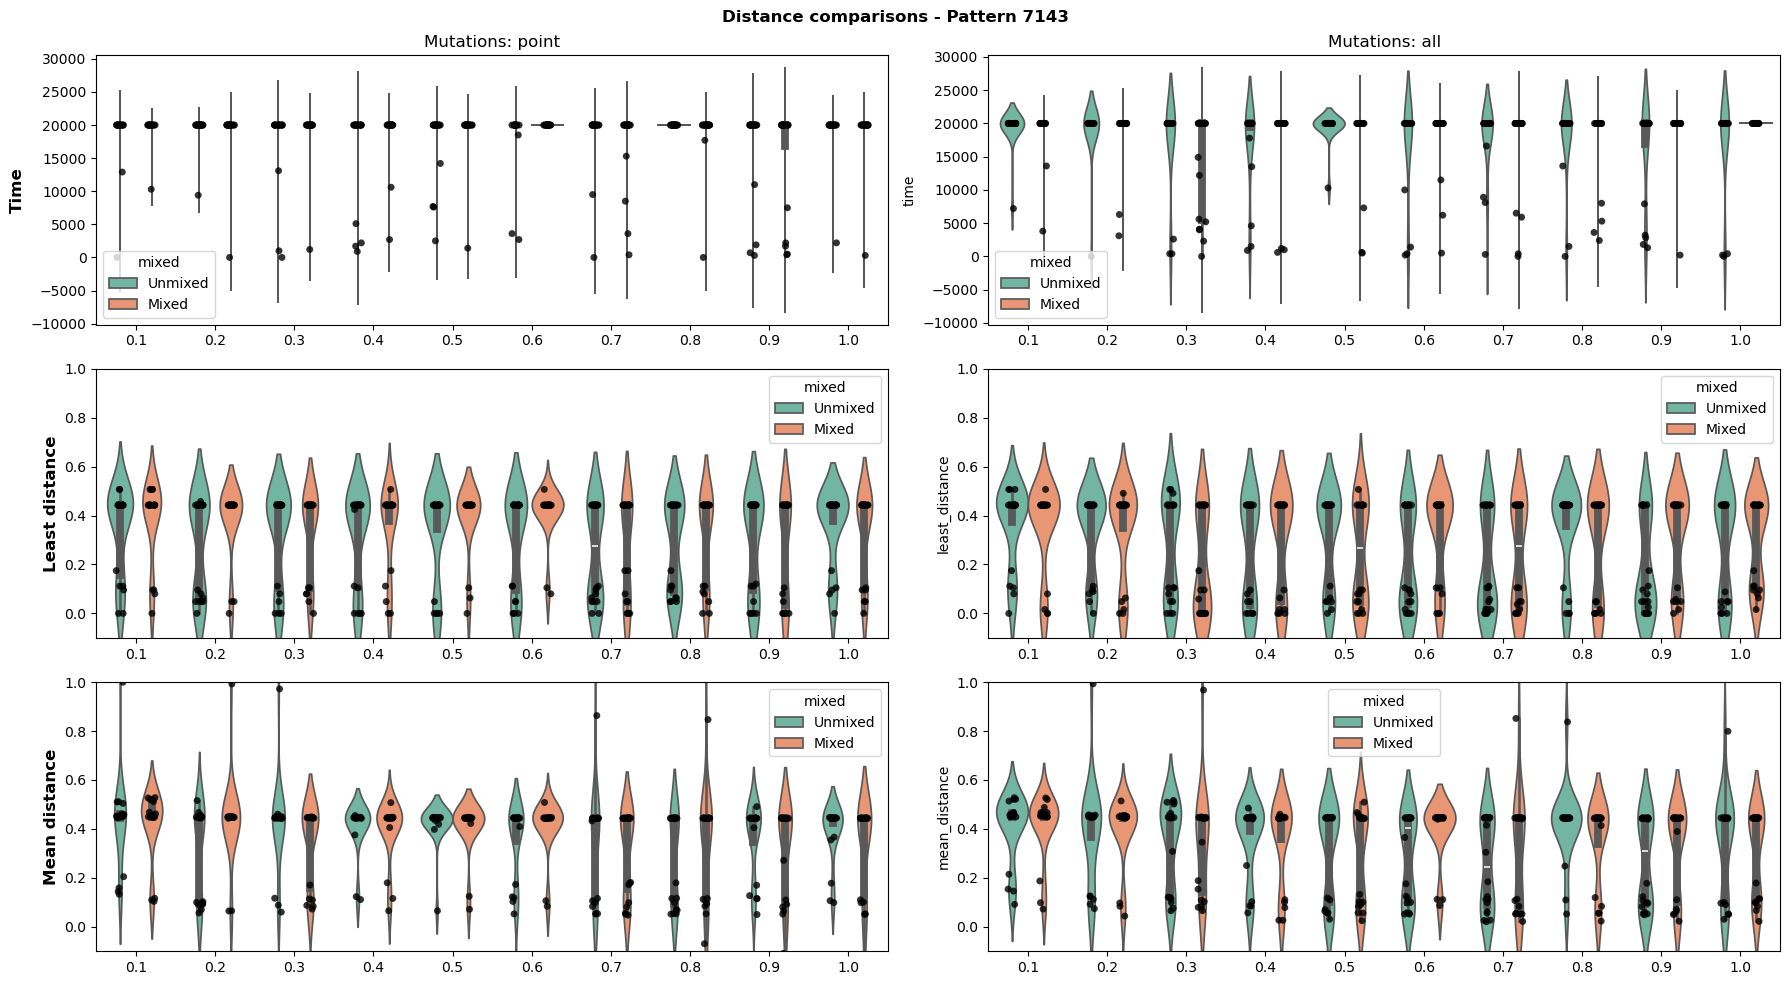

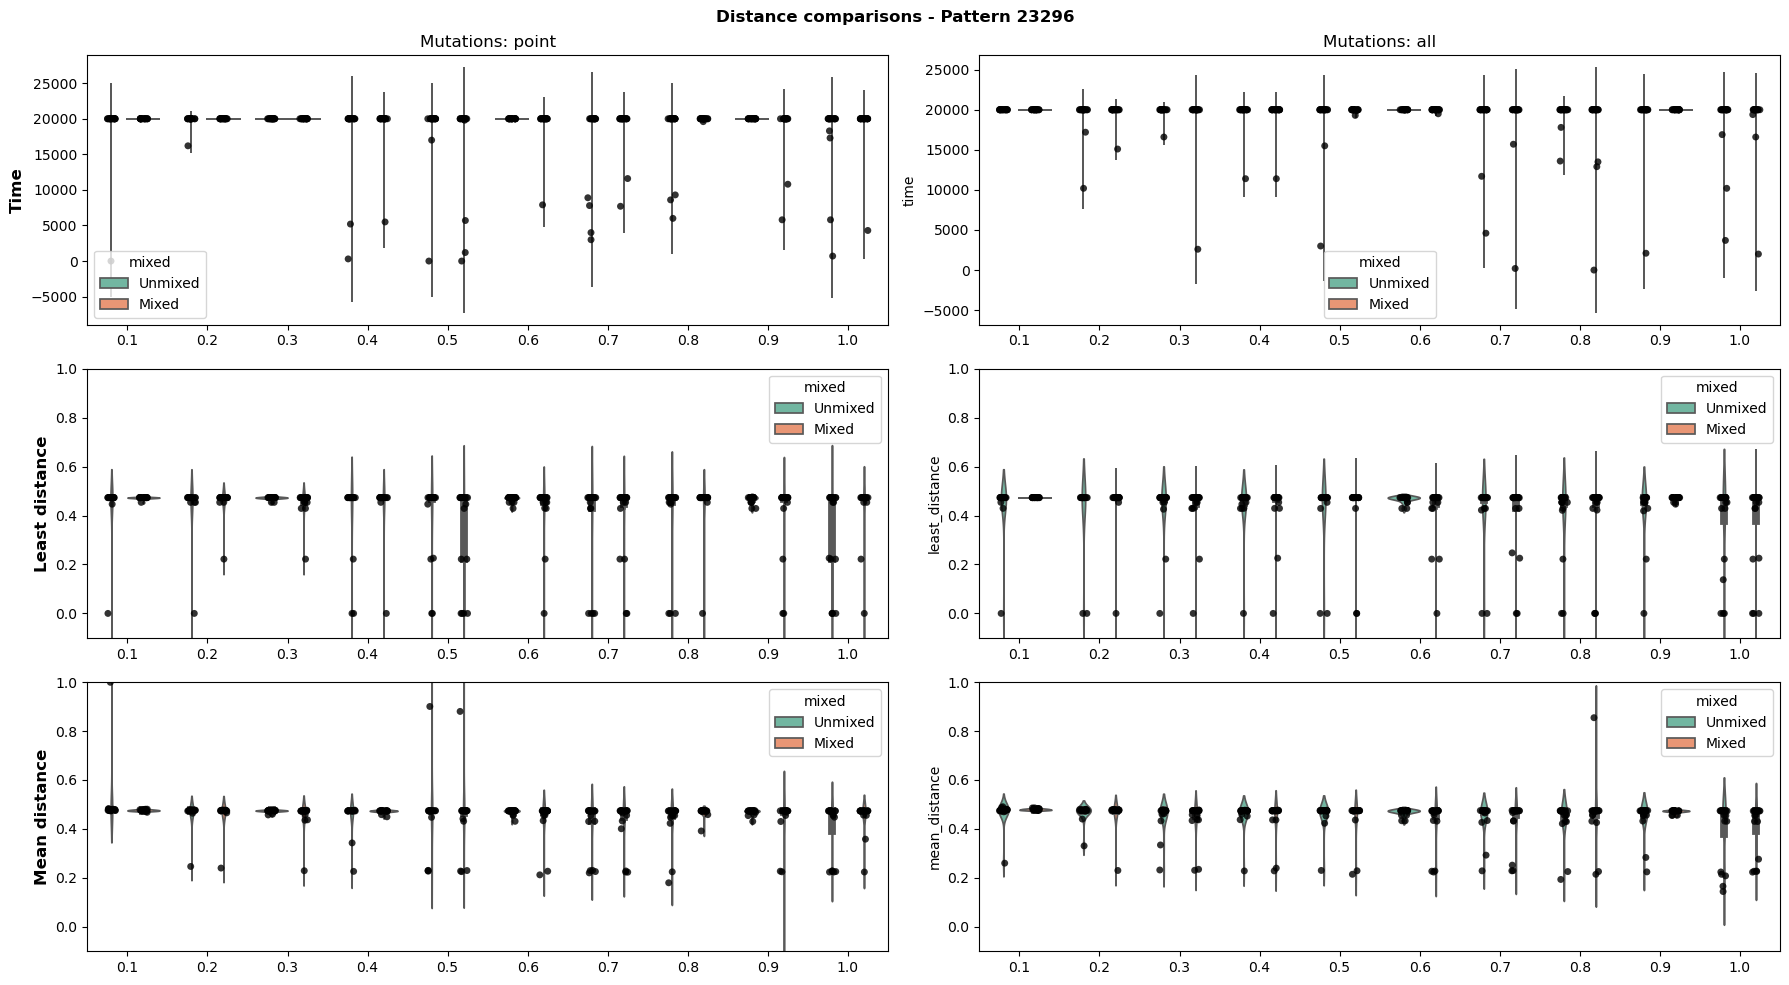

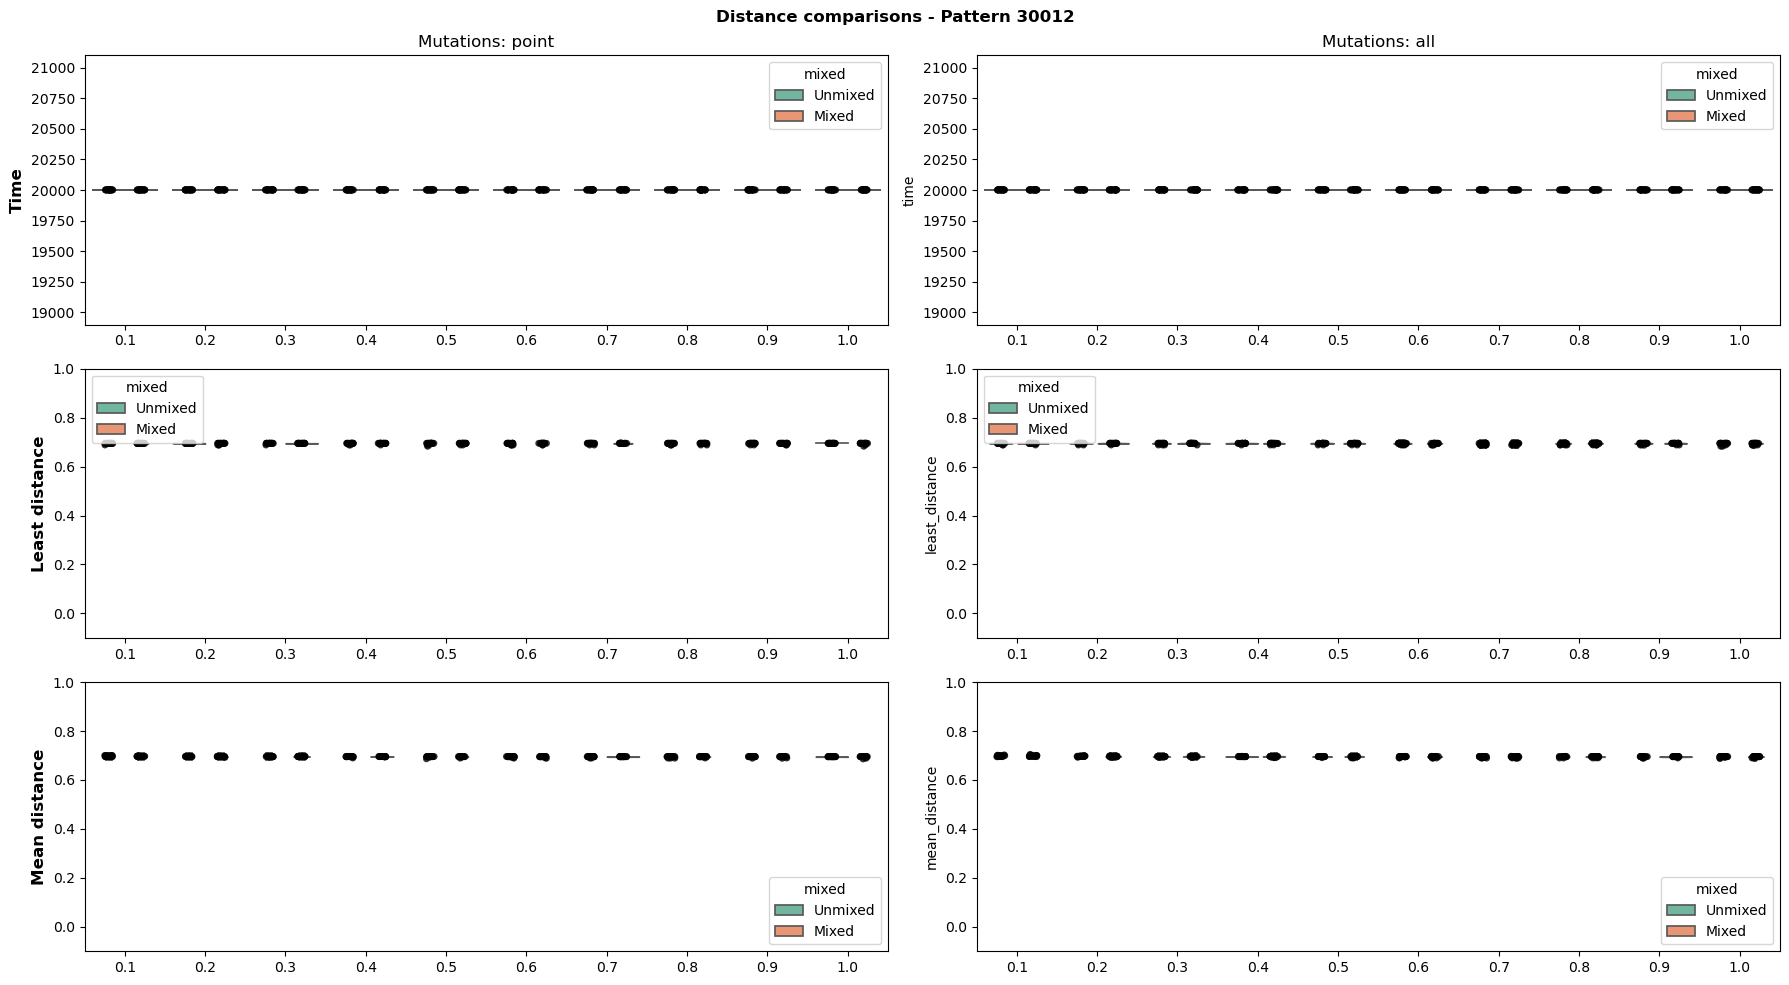

In [13]:
data_seventh = empty()
data_seventh = readerloop("Seventh_test_25x100/", patterns, data_seventh, gridsize="25x100")
distance_calculator(data_seventh)

for p in patterns:
    metaplotter(data_seventh[data_seventh["target"] == p], mode = "distance", plottype="violin",
               suptitle = "Distance comparisons - Pattern " + p,
               savepath = savedir + "distance_comparisons_p" + p + "_t20k_ss0.1-1_g25x100_10xlower_point_rates.png")

#### Eighth and ninth tests - >1 sel parameters

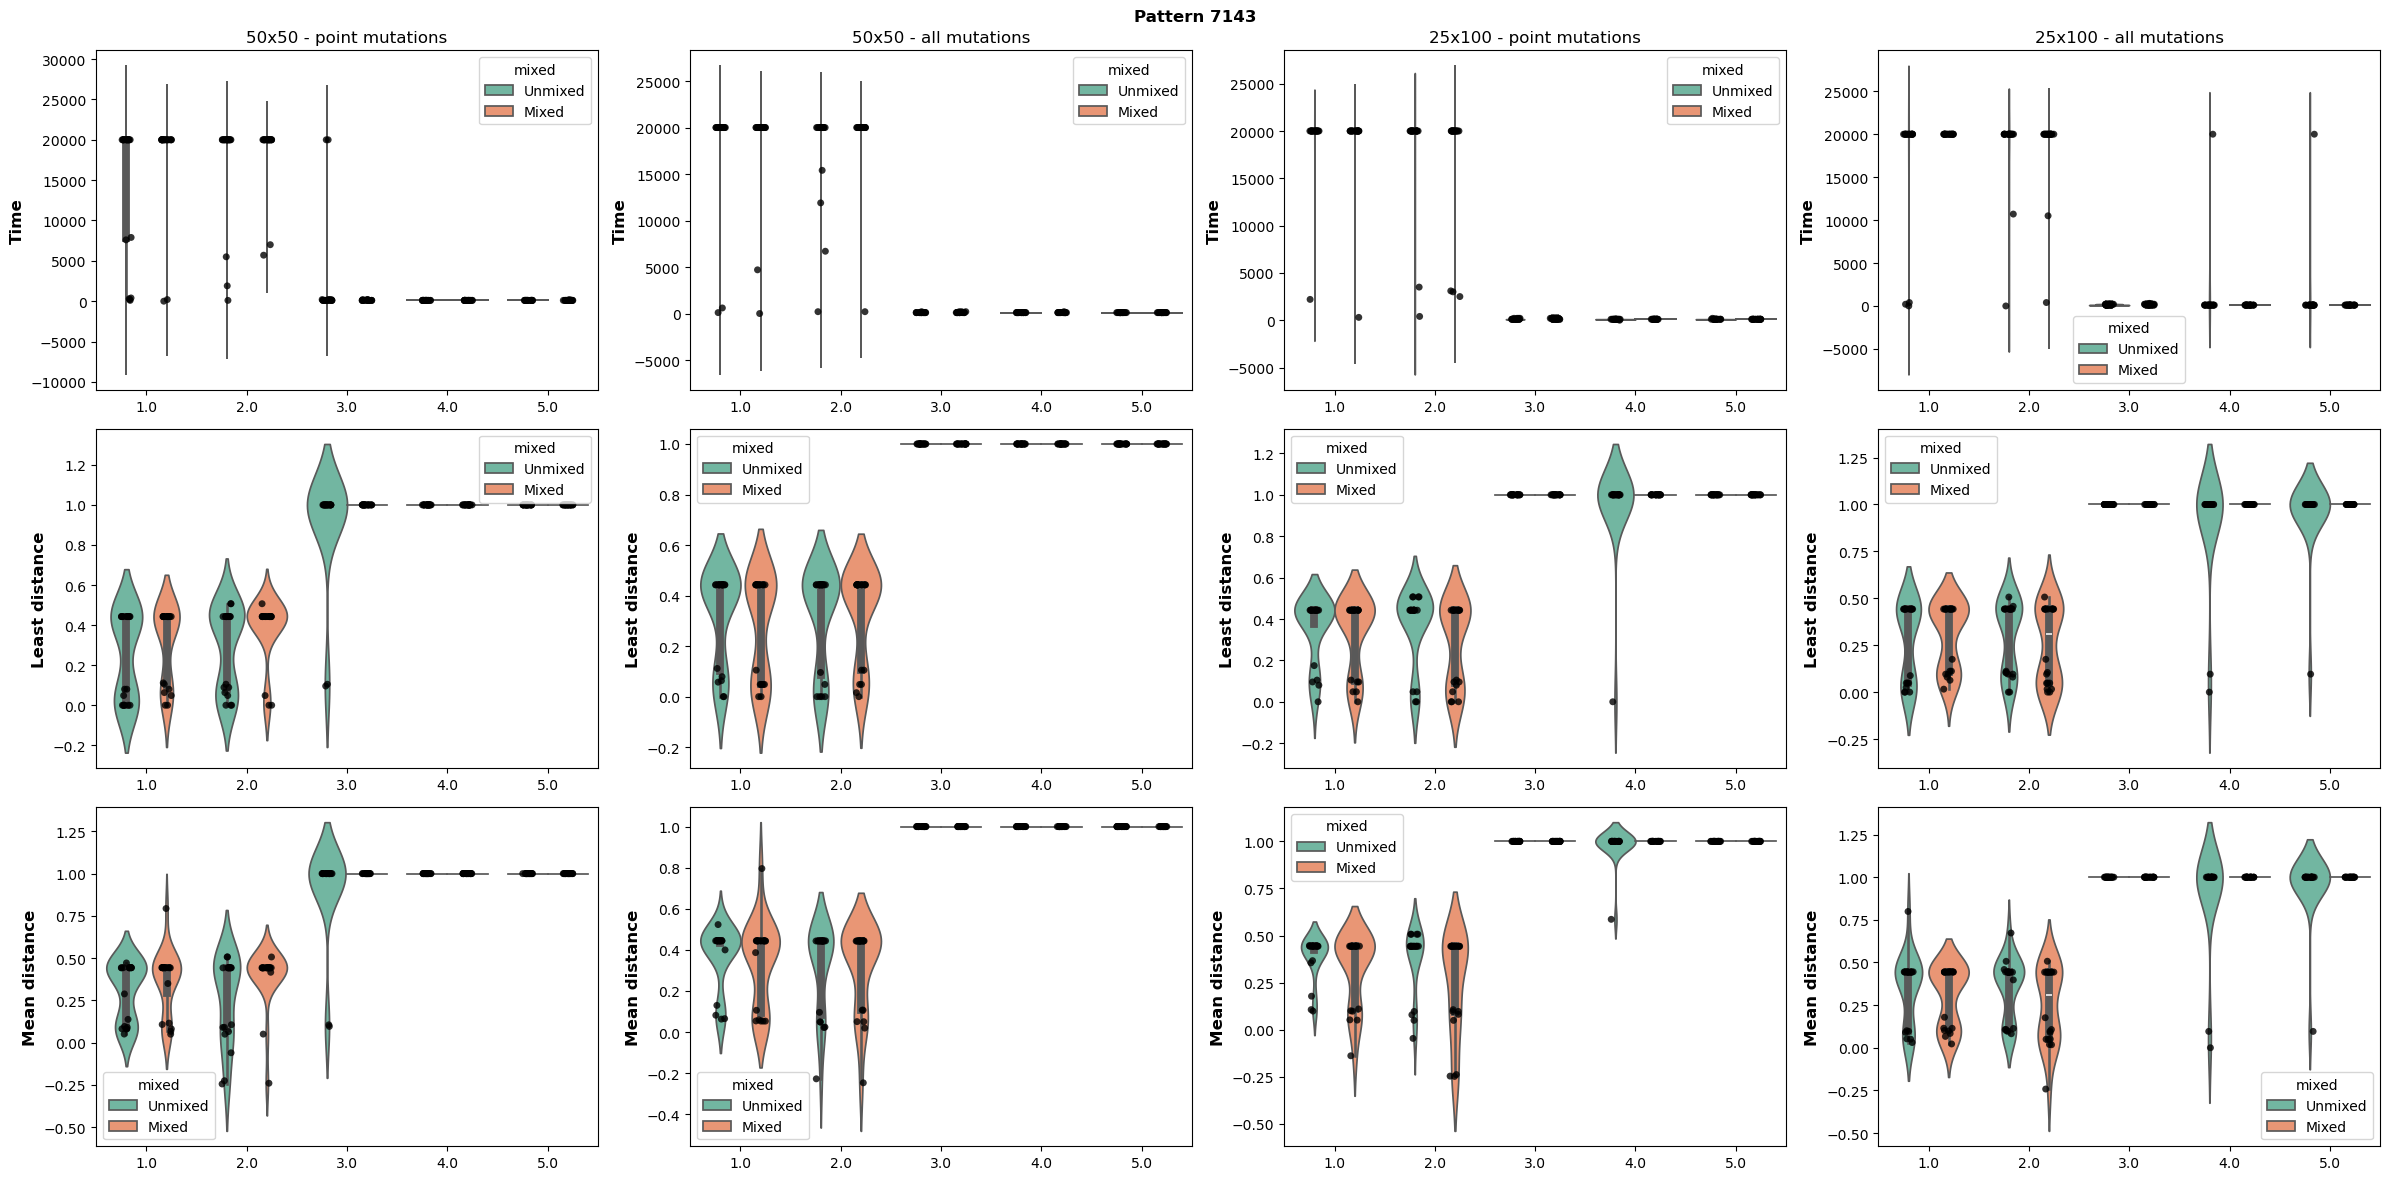

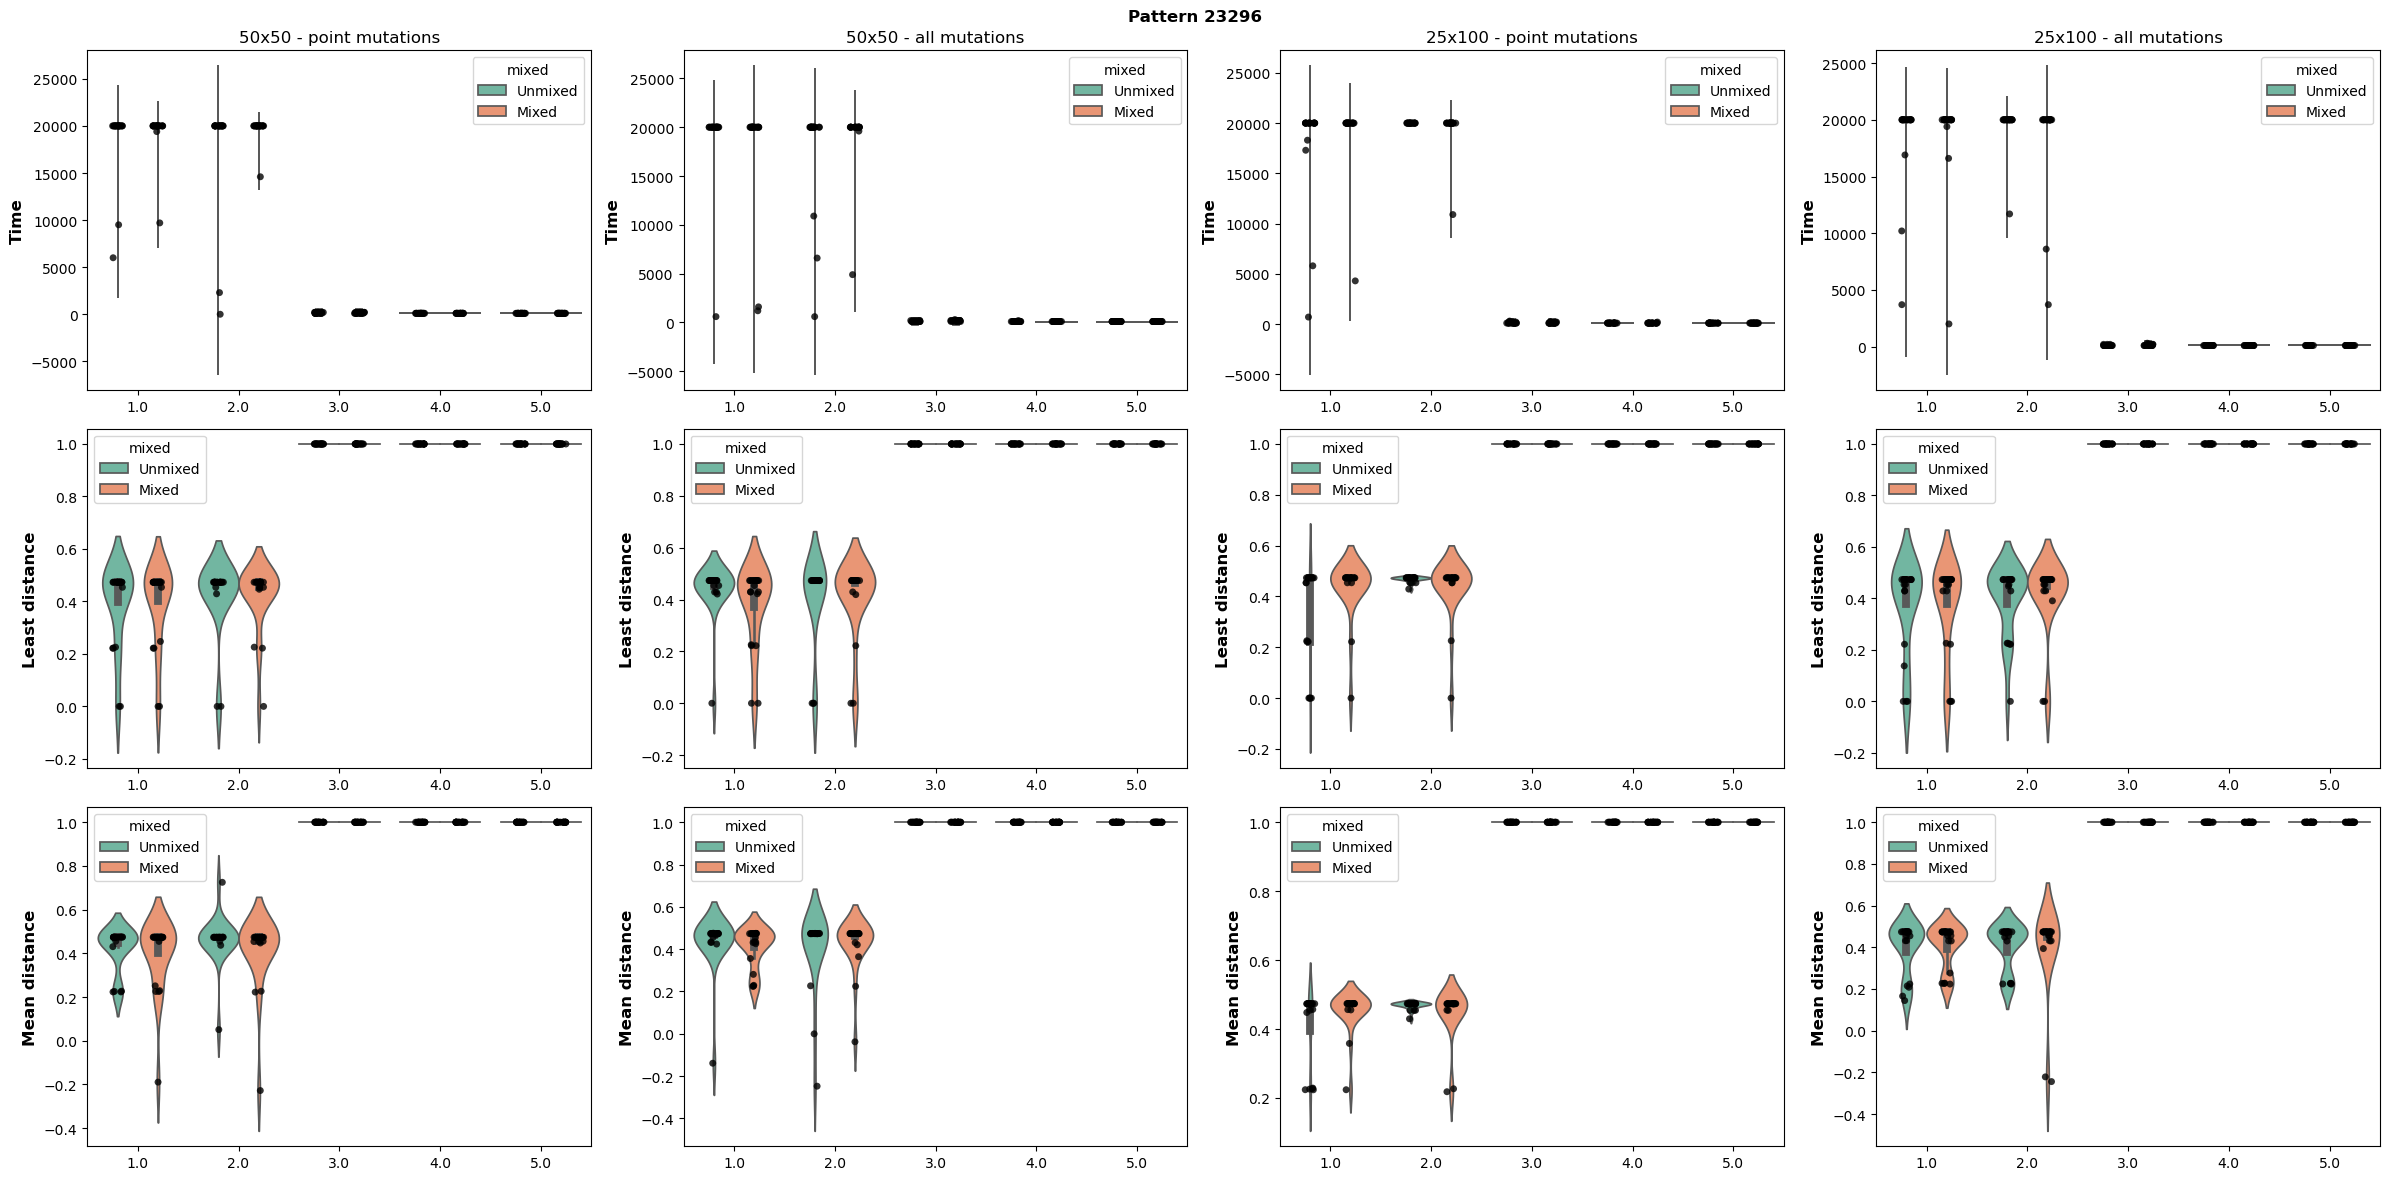

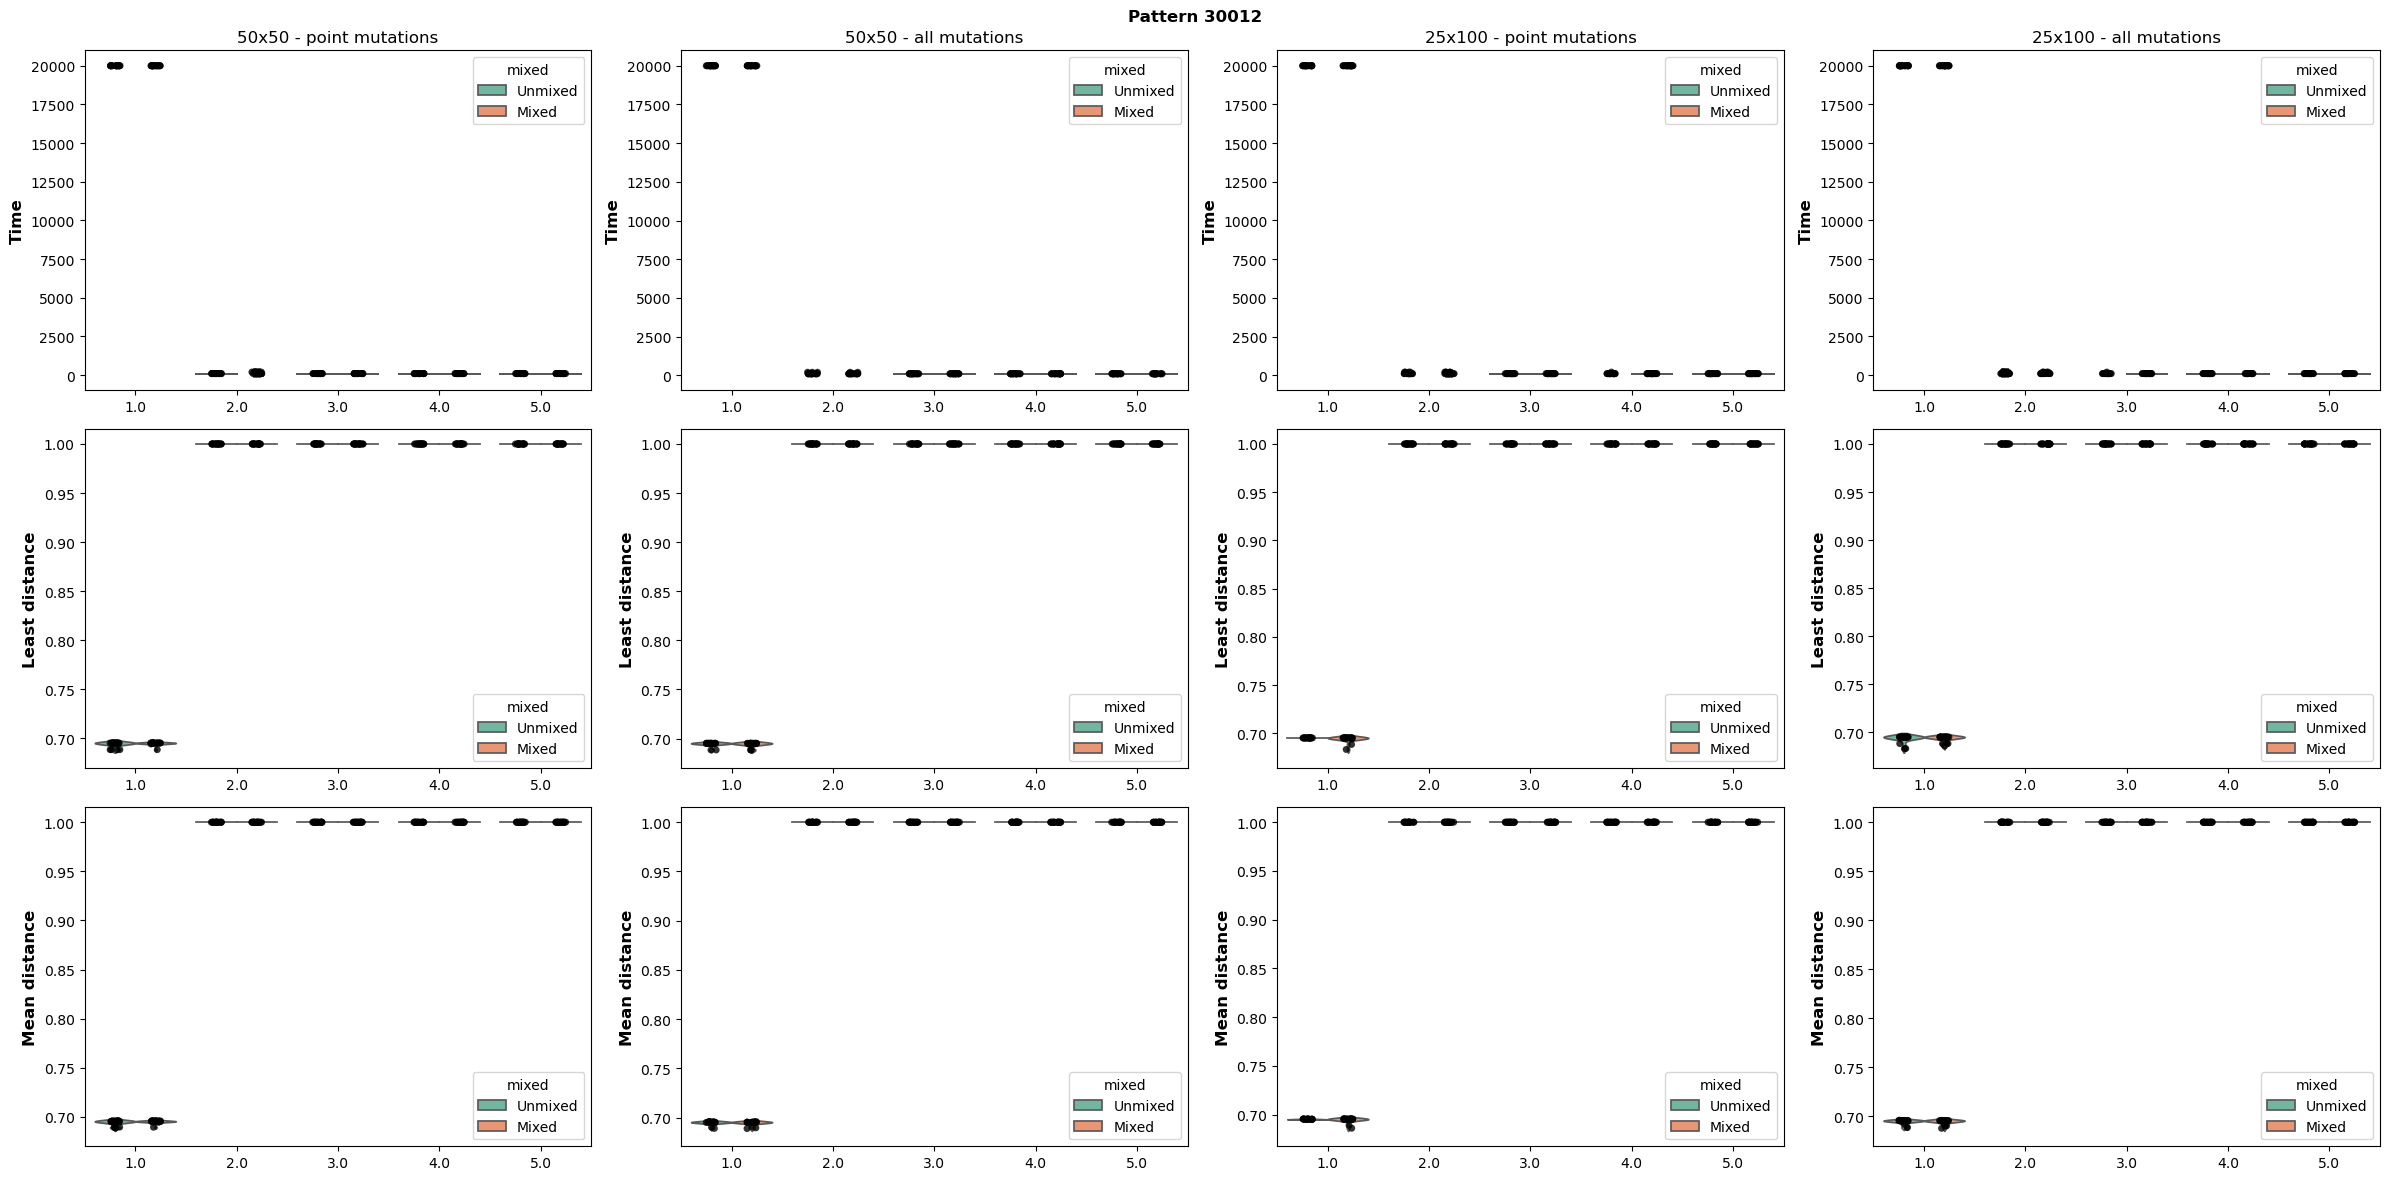

In [14]:
data_eighth = empty()
data_ninth = empty()
data_eighth = readerloop("Eighth_test_25x100/", patterns, data_eighth, sel_str_values = range(1,6),
                        gridsize="25x100")
data_ninth = readerloop("Ninth_test_50x50/", patterns, data_ninth, sel_str_values = range(1,6))


distance_calculator(data_eighth)
distance_calculator(data_ninth)

for p in patterns:
    fig, axes = plt.subplots(3, 4, figsize=(24, 12))
    metrics = ["time", "least_distance", "mean_distance"]
    titles = ["Time", "Least distance", "Mean distance"]

    for i in range(4):

        coltitle = ""
        
        if i<2:
            dslice = data_ninth[data_ninth["target"] == p]
            coltitle += "50x50 - "
        else:
            dslice = data_eighth[data_eighth["target"] == p]
            coltitle += "25x100 - "
        if i%2 == 0:
            dslice = dslice[dslice["mutations"] == "point"]
            coltitle += "point mutations"
        else:
            dslice = dslice[dslice["mutations"] == "all"]
            coltitle += "all mutations"
    
        for ax, metric, title in zip(axes.T[i], metrics, titles):
            
            
            simple_plotter_violin(ax, dslice, x="sel_str", y=metric)
            ax.set_xlabel("", fontsize=12, fontweight="bold")
            ax.set_ylabel(title, fontsize=12, fontweight="bold")
            
    
        axes[0][i].set_title(coltitle)
    plt.suptitle("Pattern " + p, fontweight="bold")
    plt.tight_layout()
    plt.savefig(savedir + "grid_comparisons_p" + p + "_t20k_ss1-5_10xlower_point_rates.png")
    plt.show()


#### Tenth and eleventh test - 100k long simulations

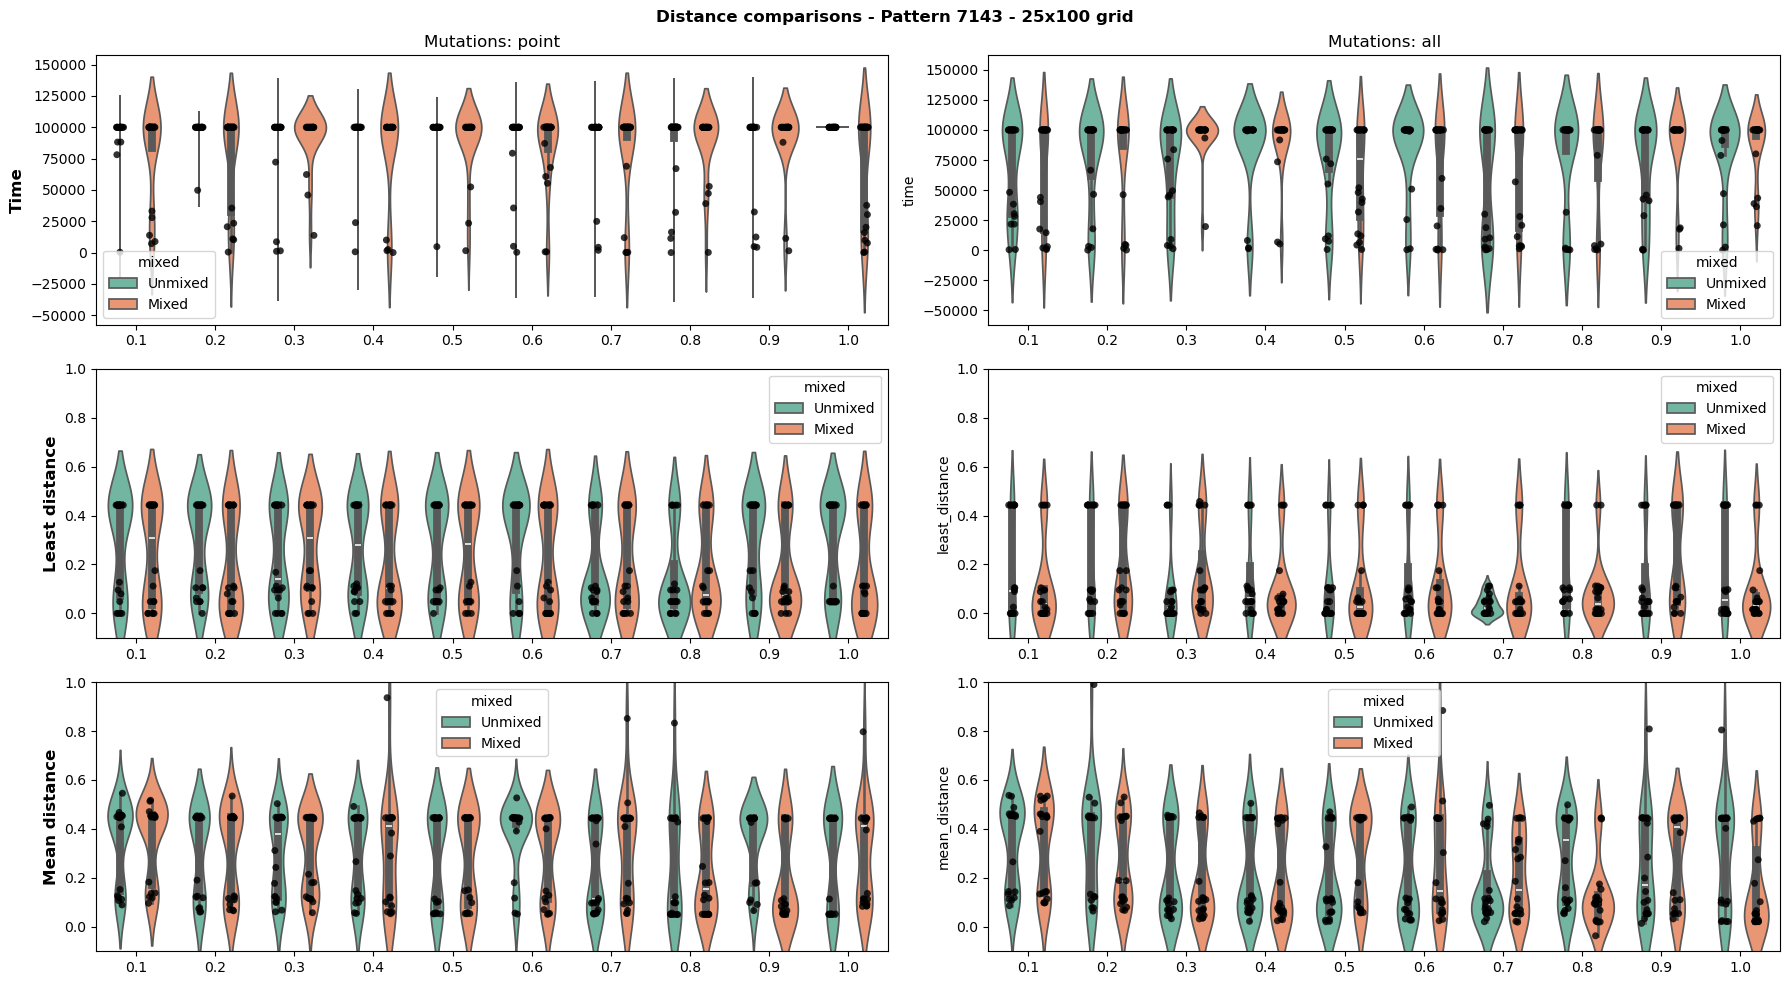

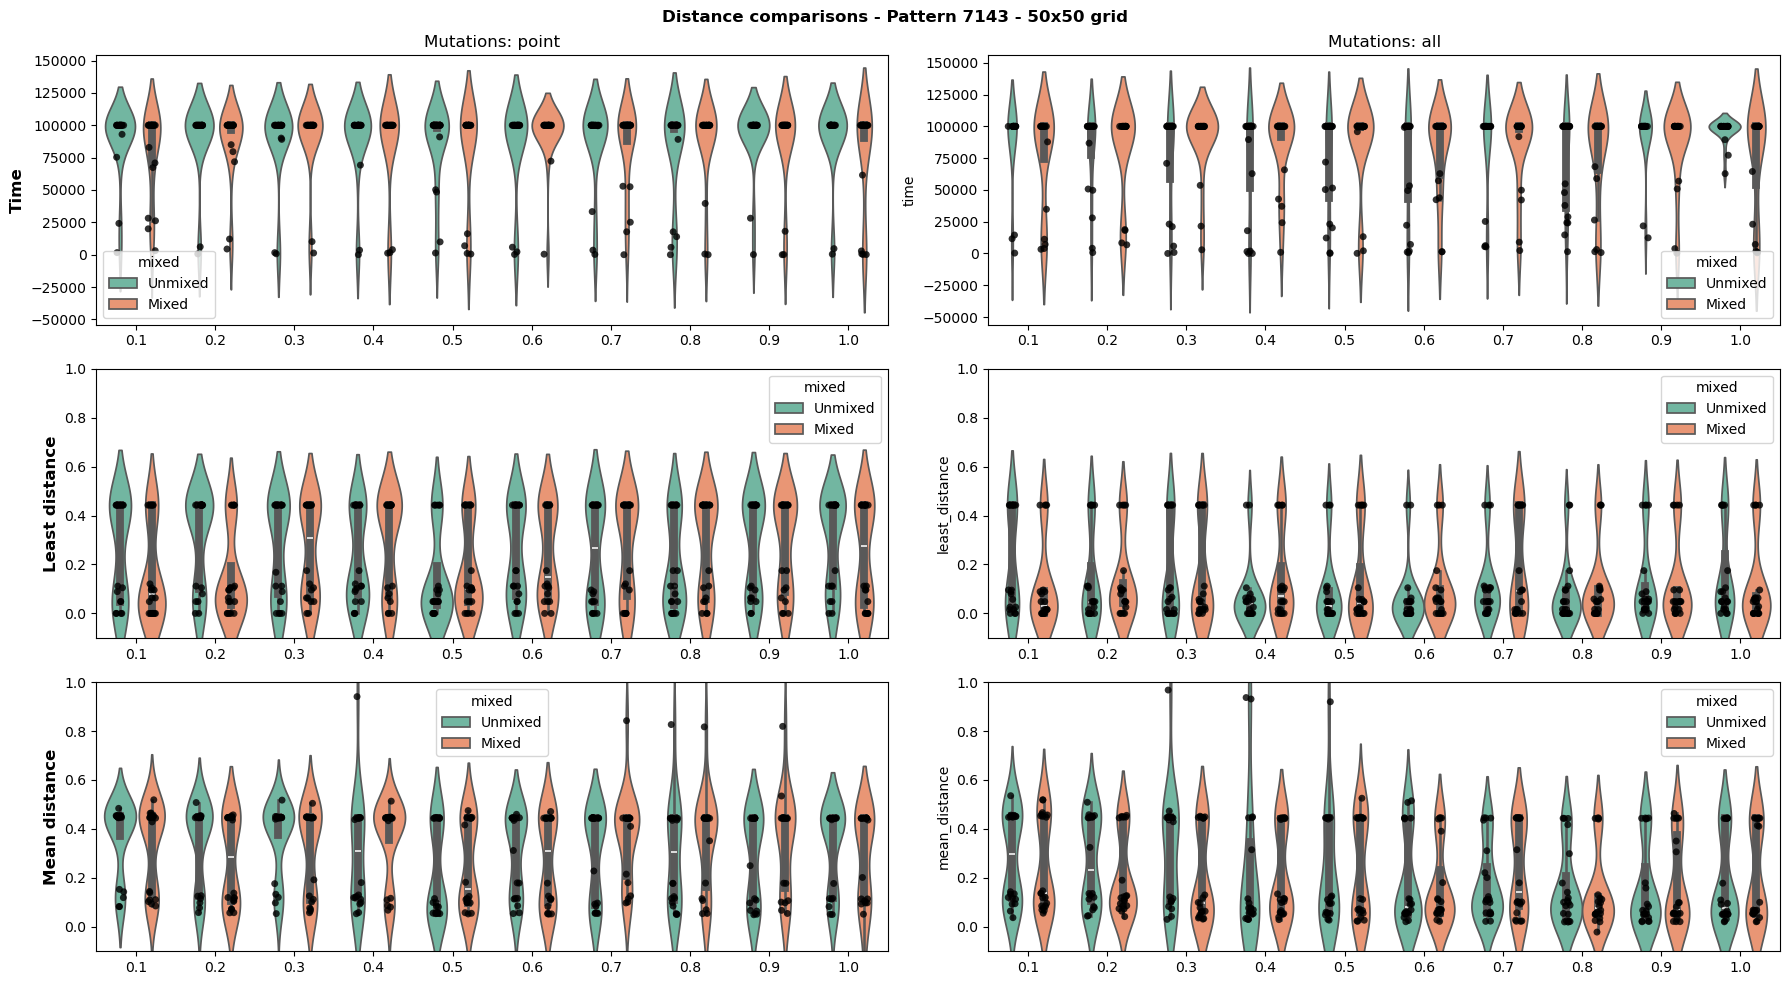

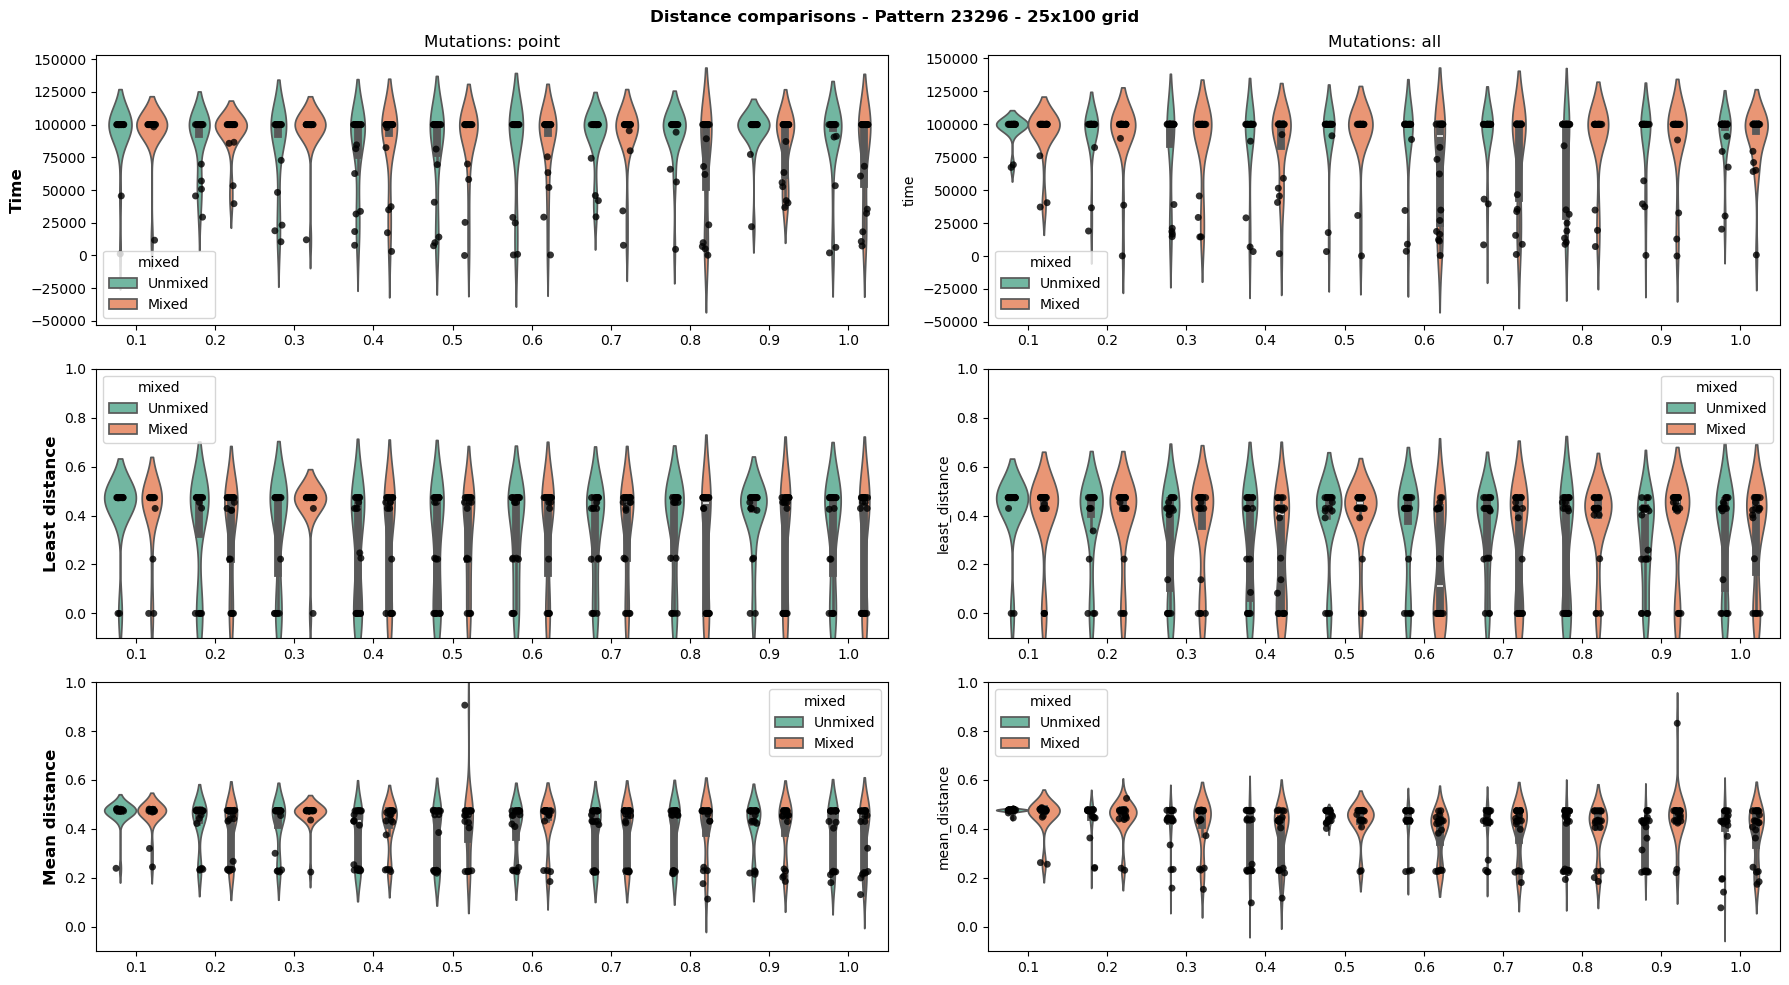

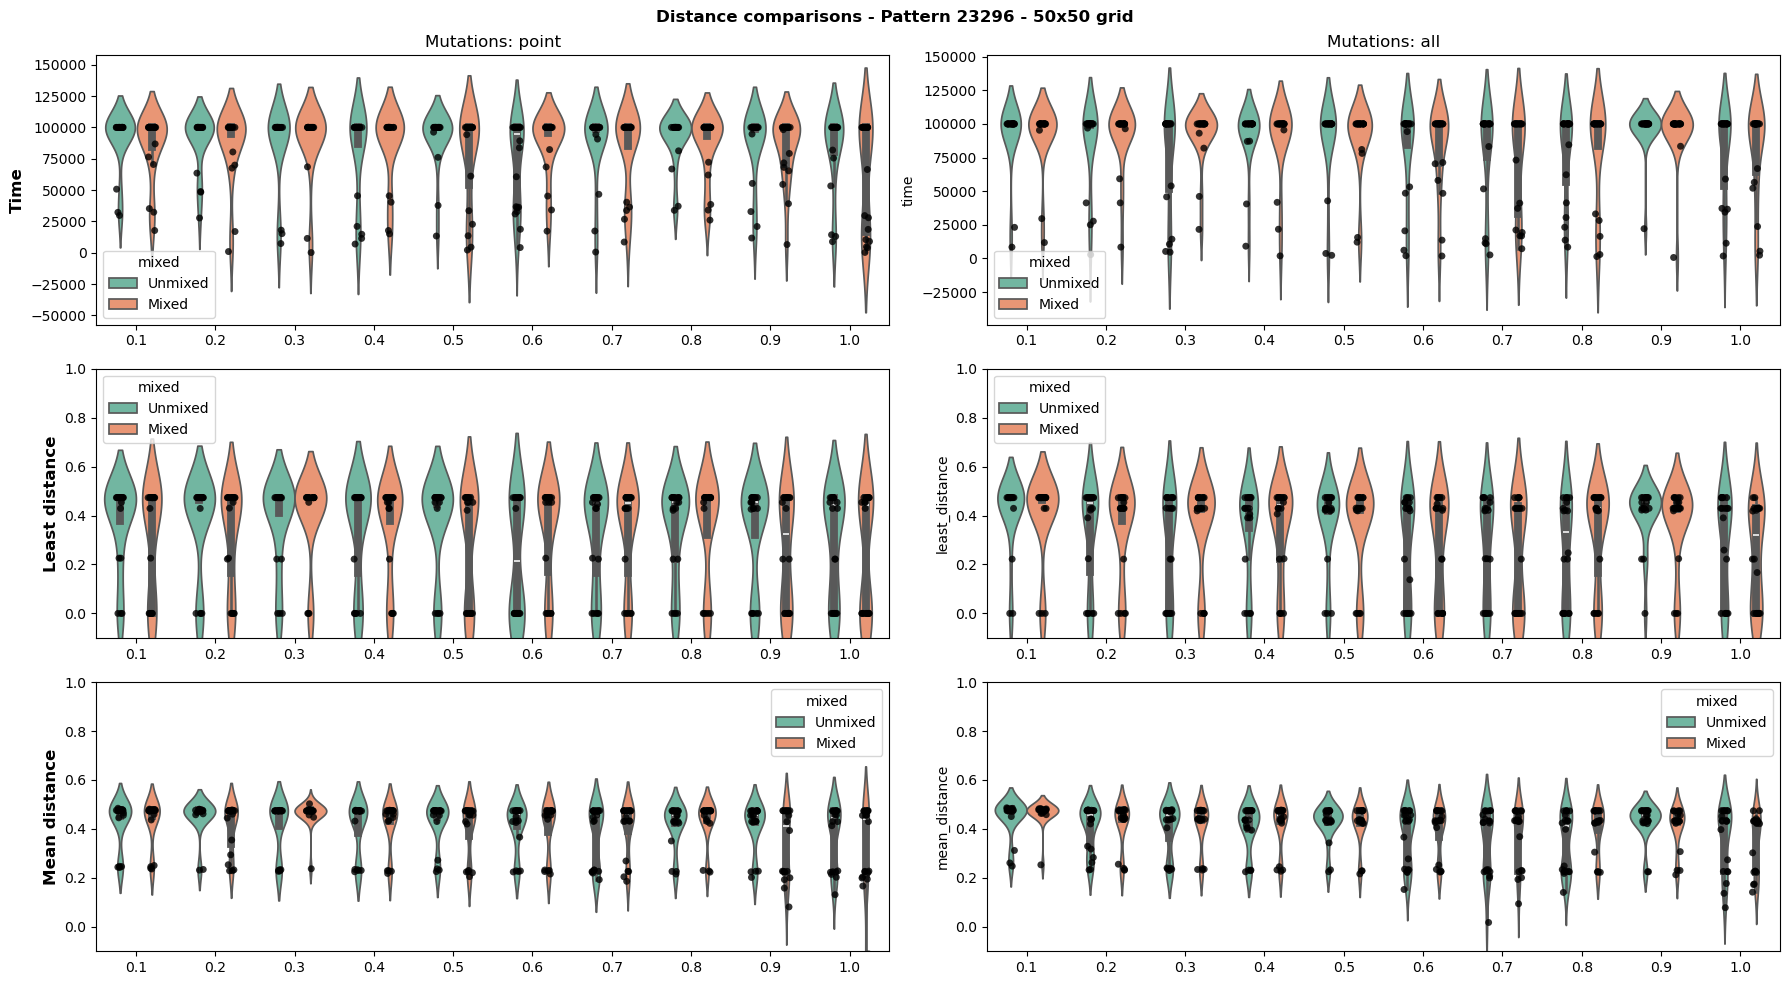

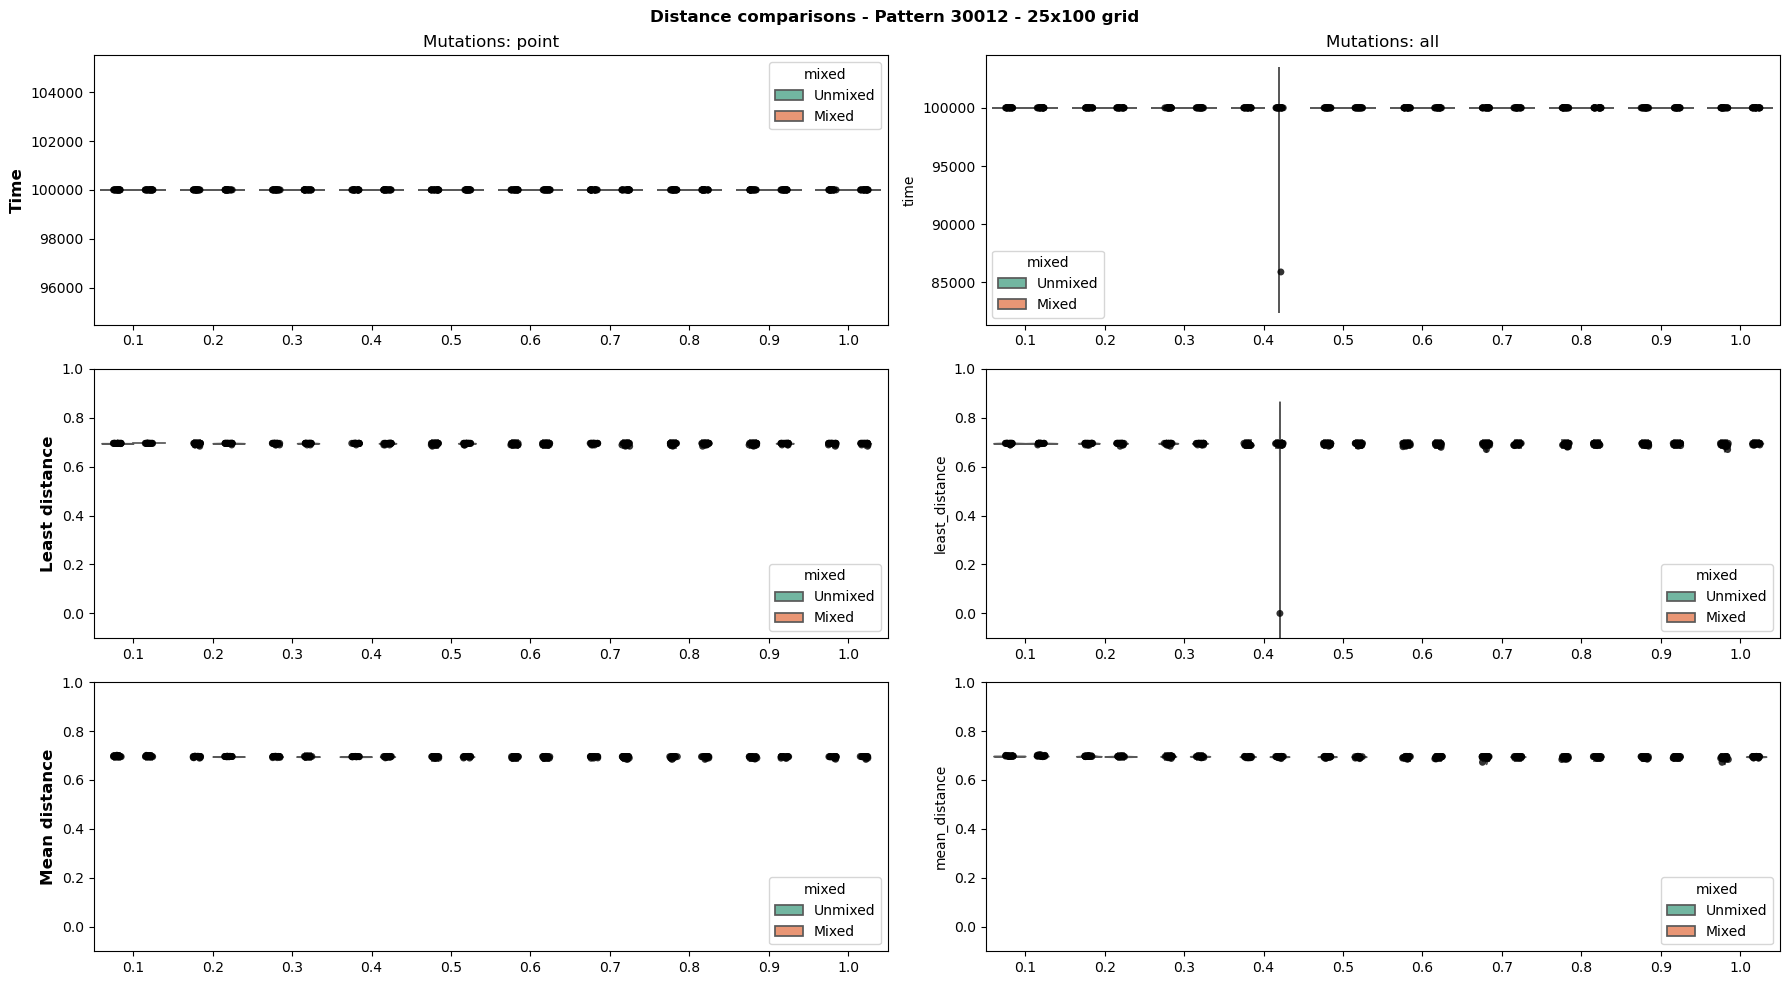

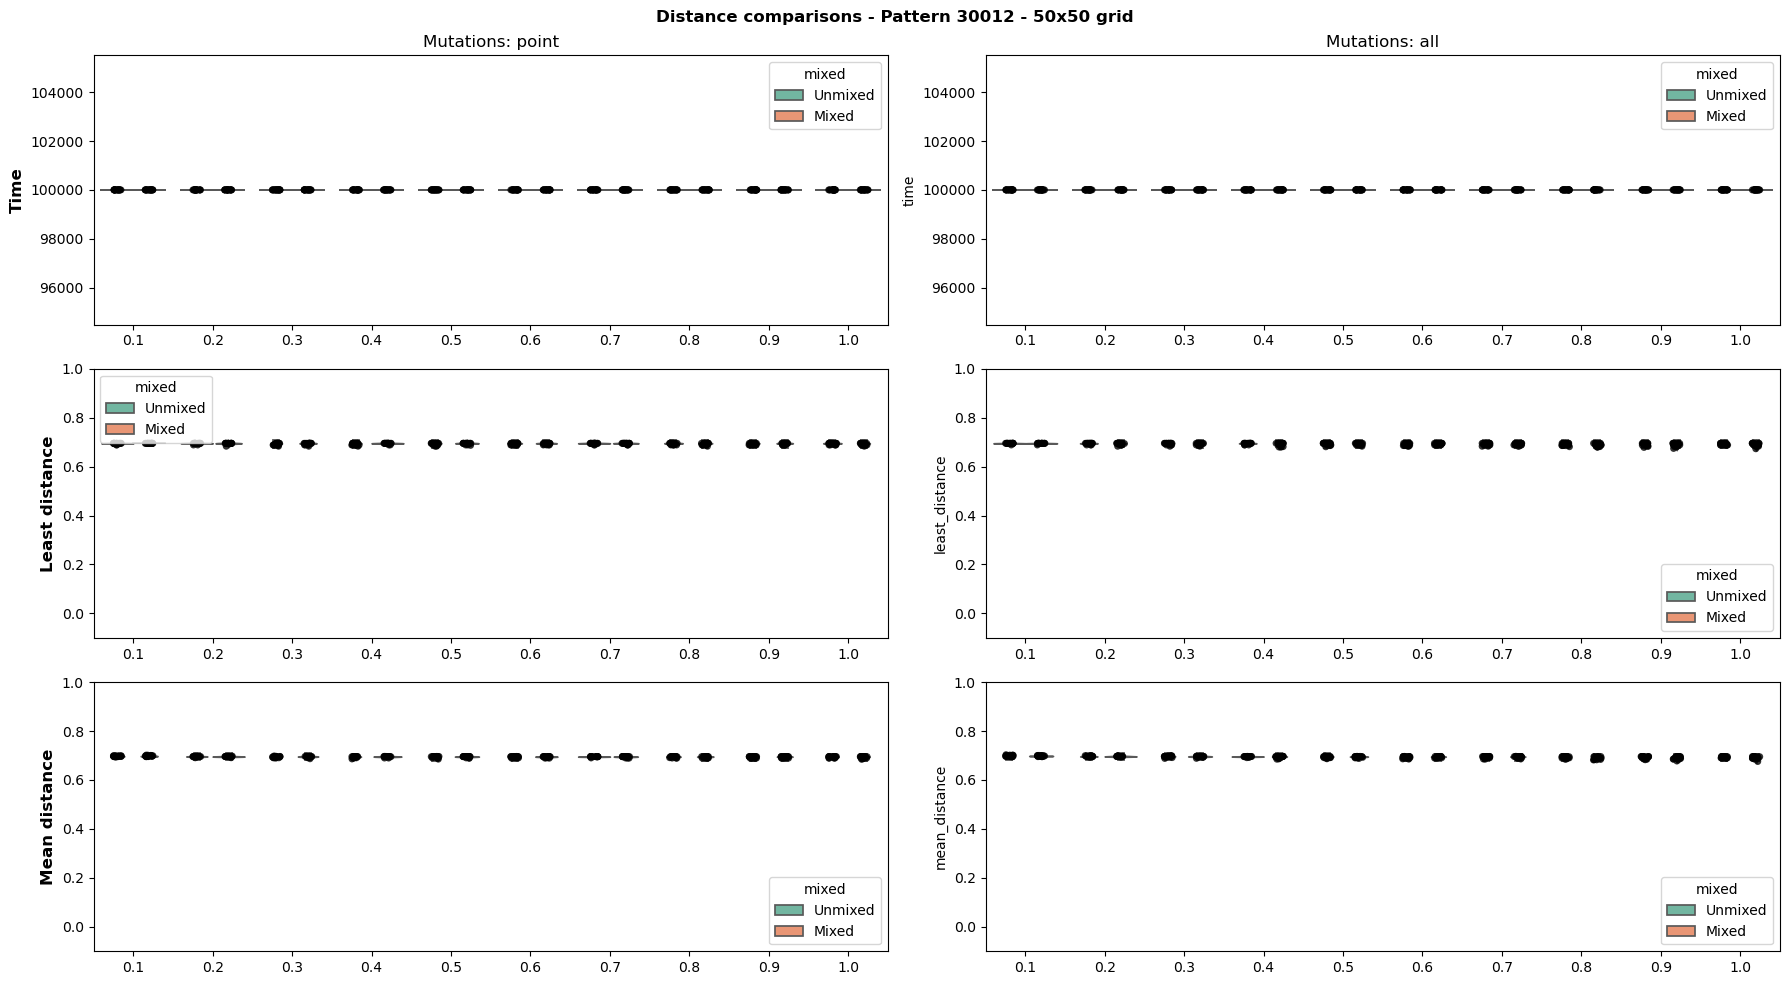

In [15]:
data_tenth = empty()
data_eleventh = empty()
data_tenth = readerloop("Tenth_test_25x100/", patterns, data_tenth, simtime=100000, gridsize="25x100")
data_eleventh = readerloop("Eleventh_test_50x50/", patterns, data_eleventh, simtime=100000)


distance_calculator(data_tenth)
distance_calculator(data_eleventh)


for p in patterns:
    metaplotter(data_tenth[data_tenth["target"] == p], mode = "distance", plottype="violin",
               suptitle = "Distance comparisons - Pattern " + p + " - 25x100 grid",
               savepath = savedir + "distance_comparisons_p" + p + "_t100k_ss0.1-1_g25x100_10xlower_point_rates.png")
    metaplotter(data_eleventh[data_eleventh["target"] == p], mode = "distance", plottype="violin",
               suptitle = "Distance comparisons - Pattern " + p + " - 50x50 grid",
               savepath = savedir + "distance_comparisons_p" + p + "_t100k_ss0.1-1_g50x50_10xlower_point_rates.png")

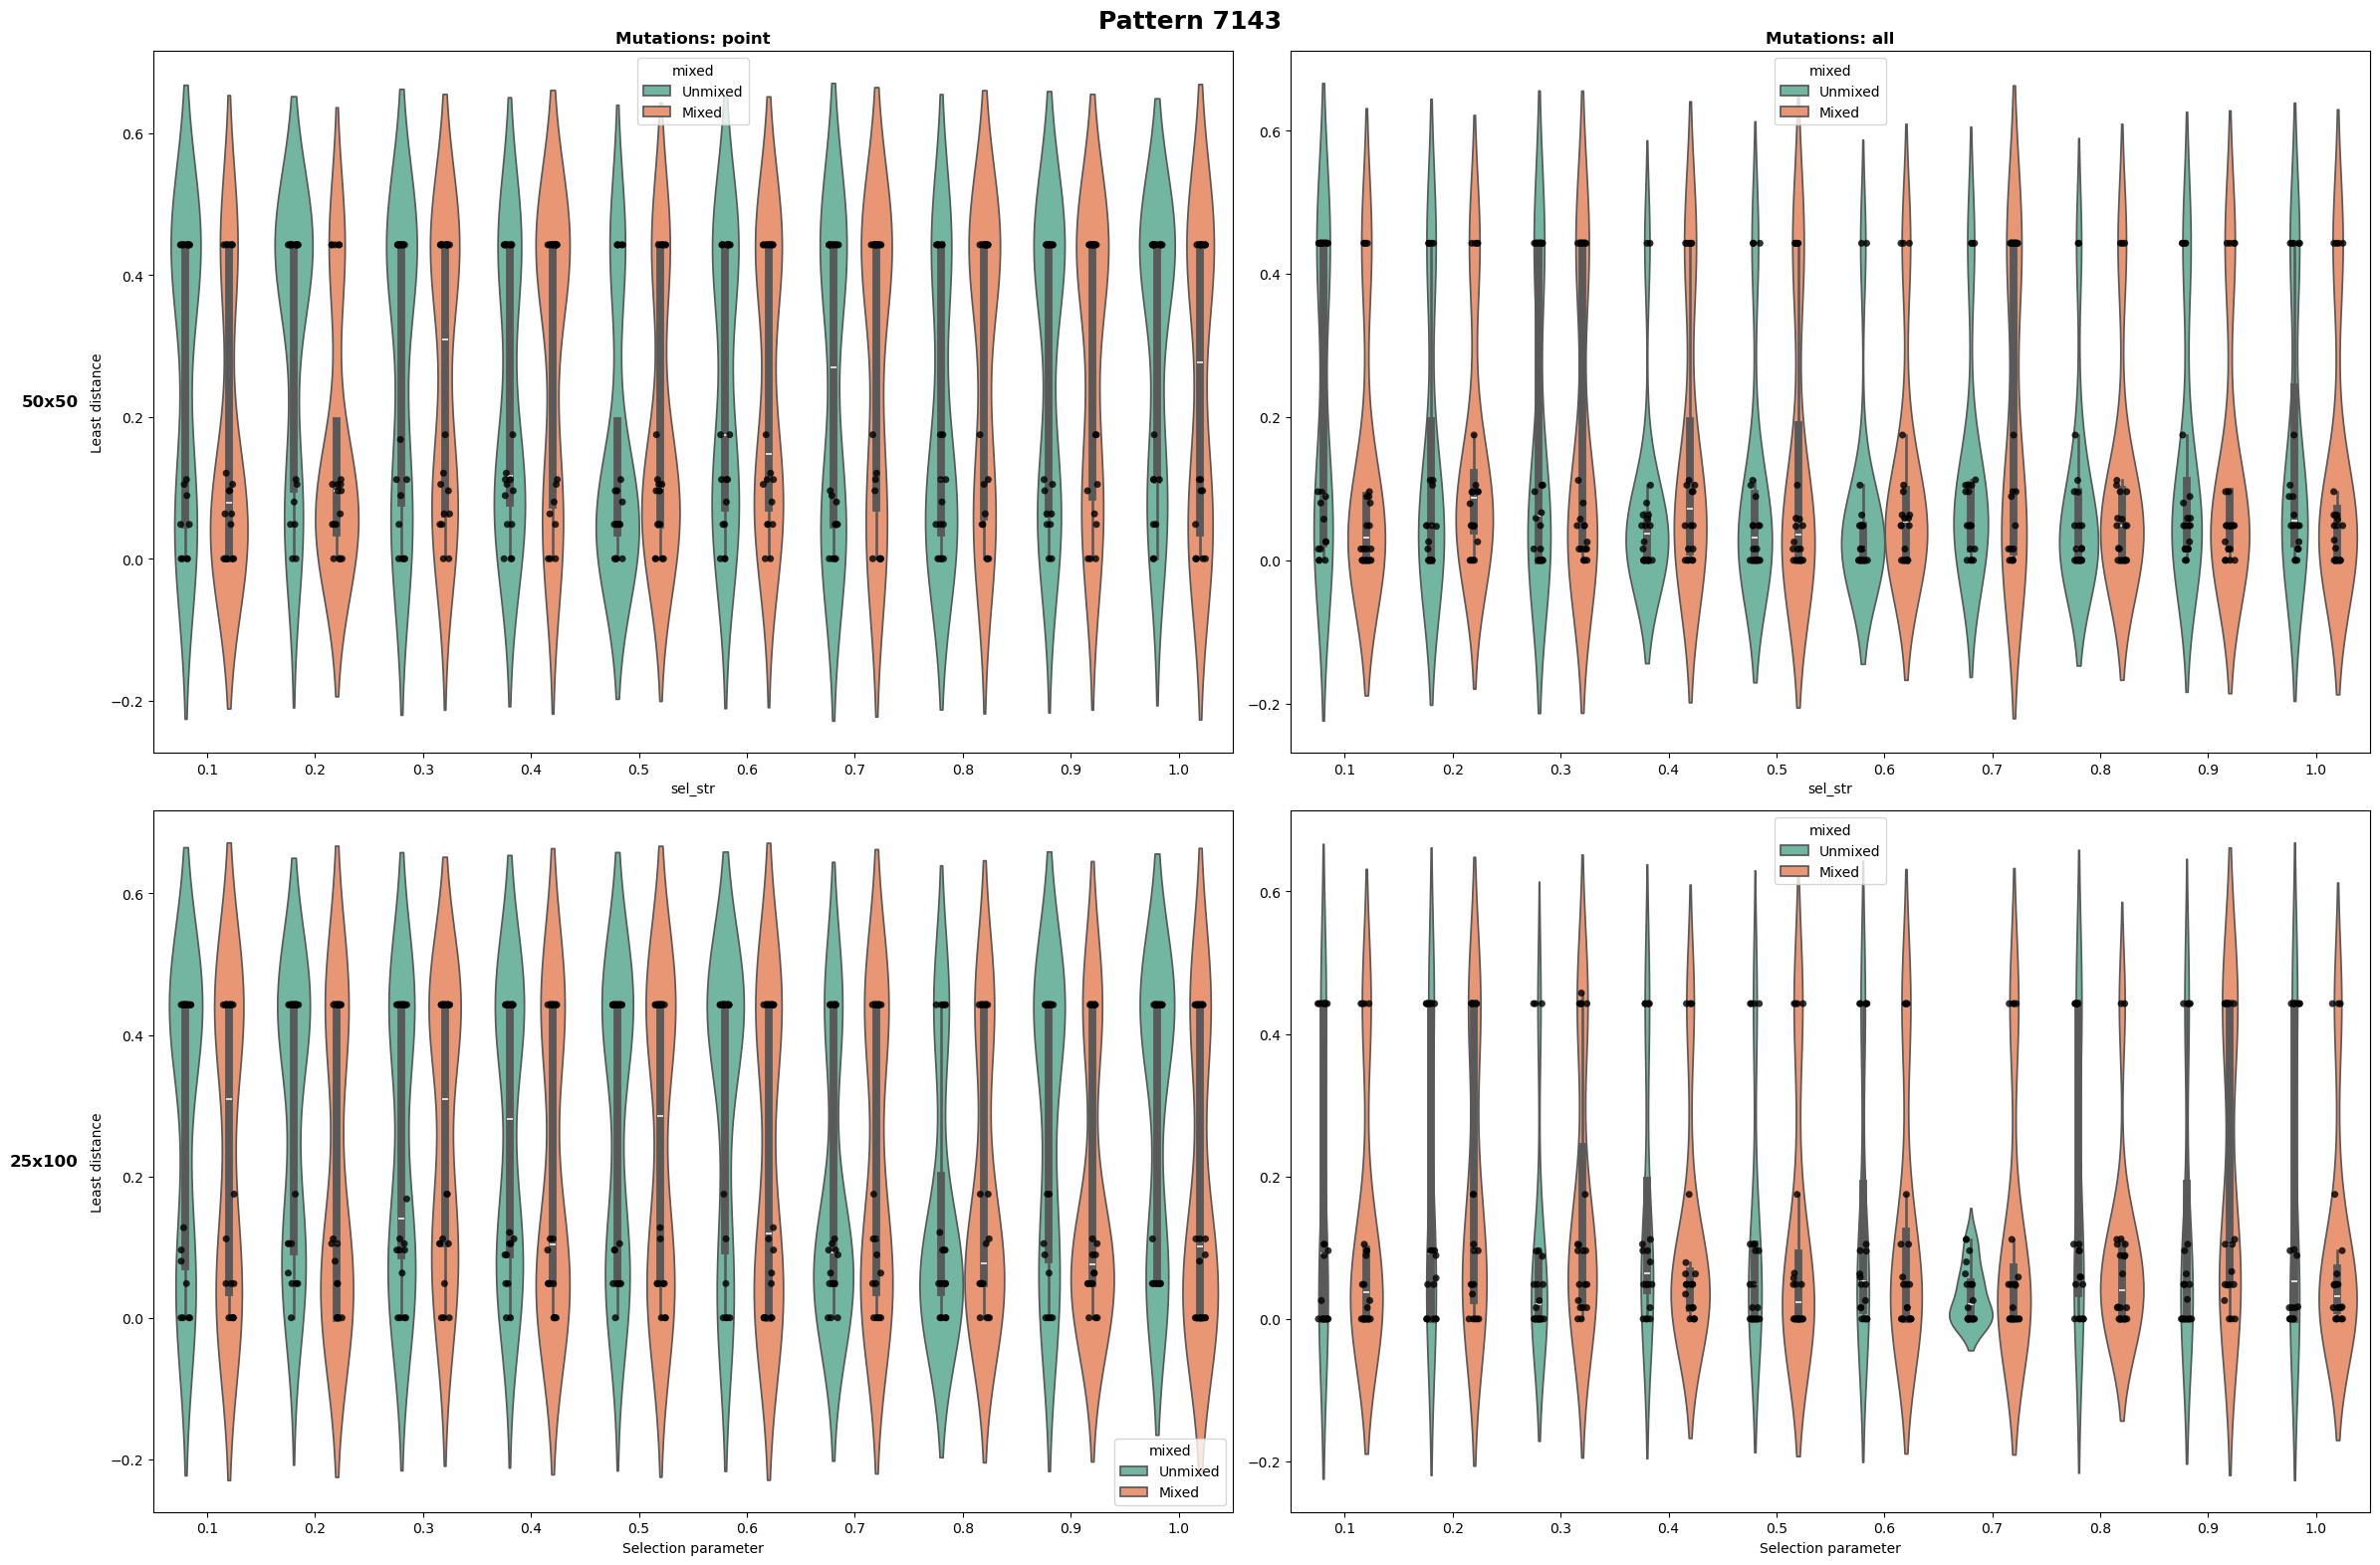

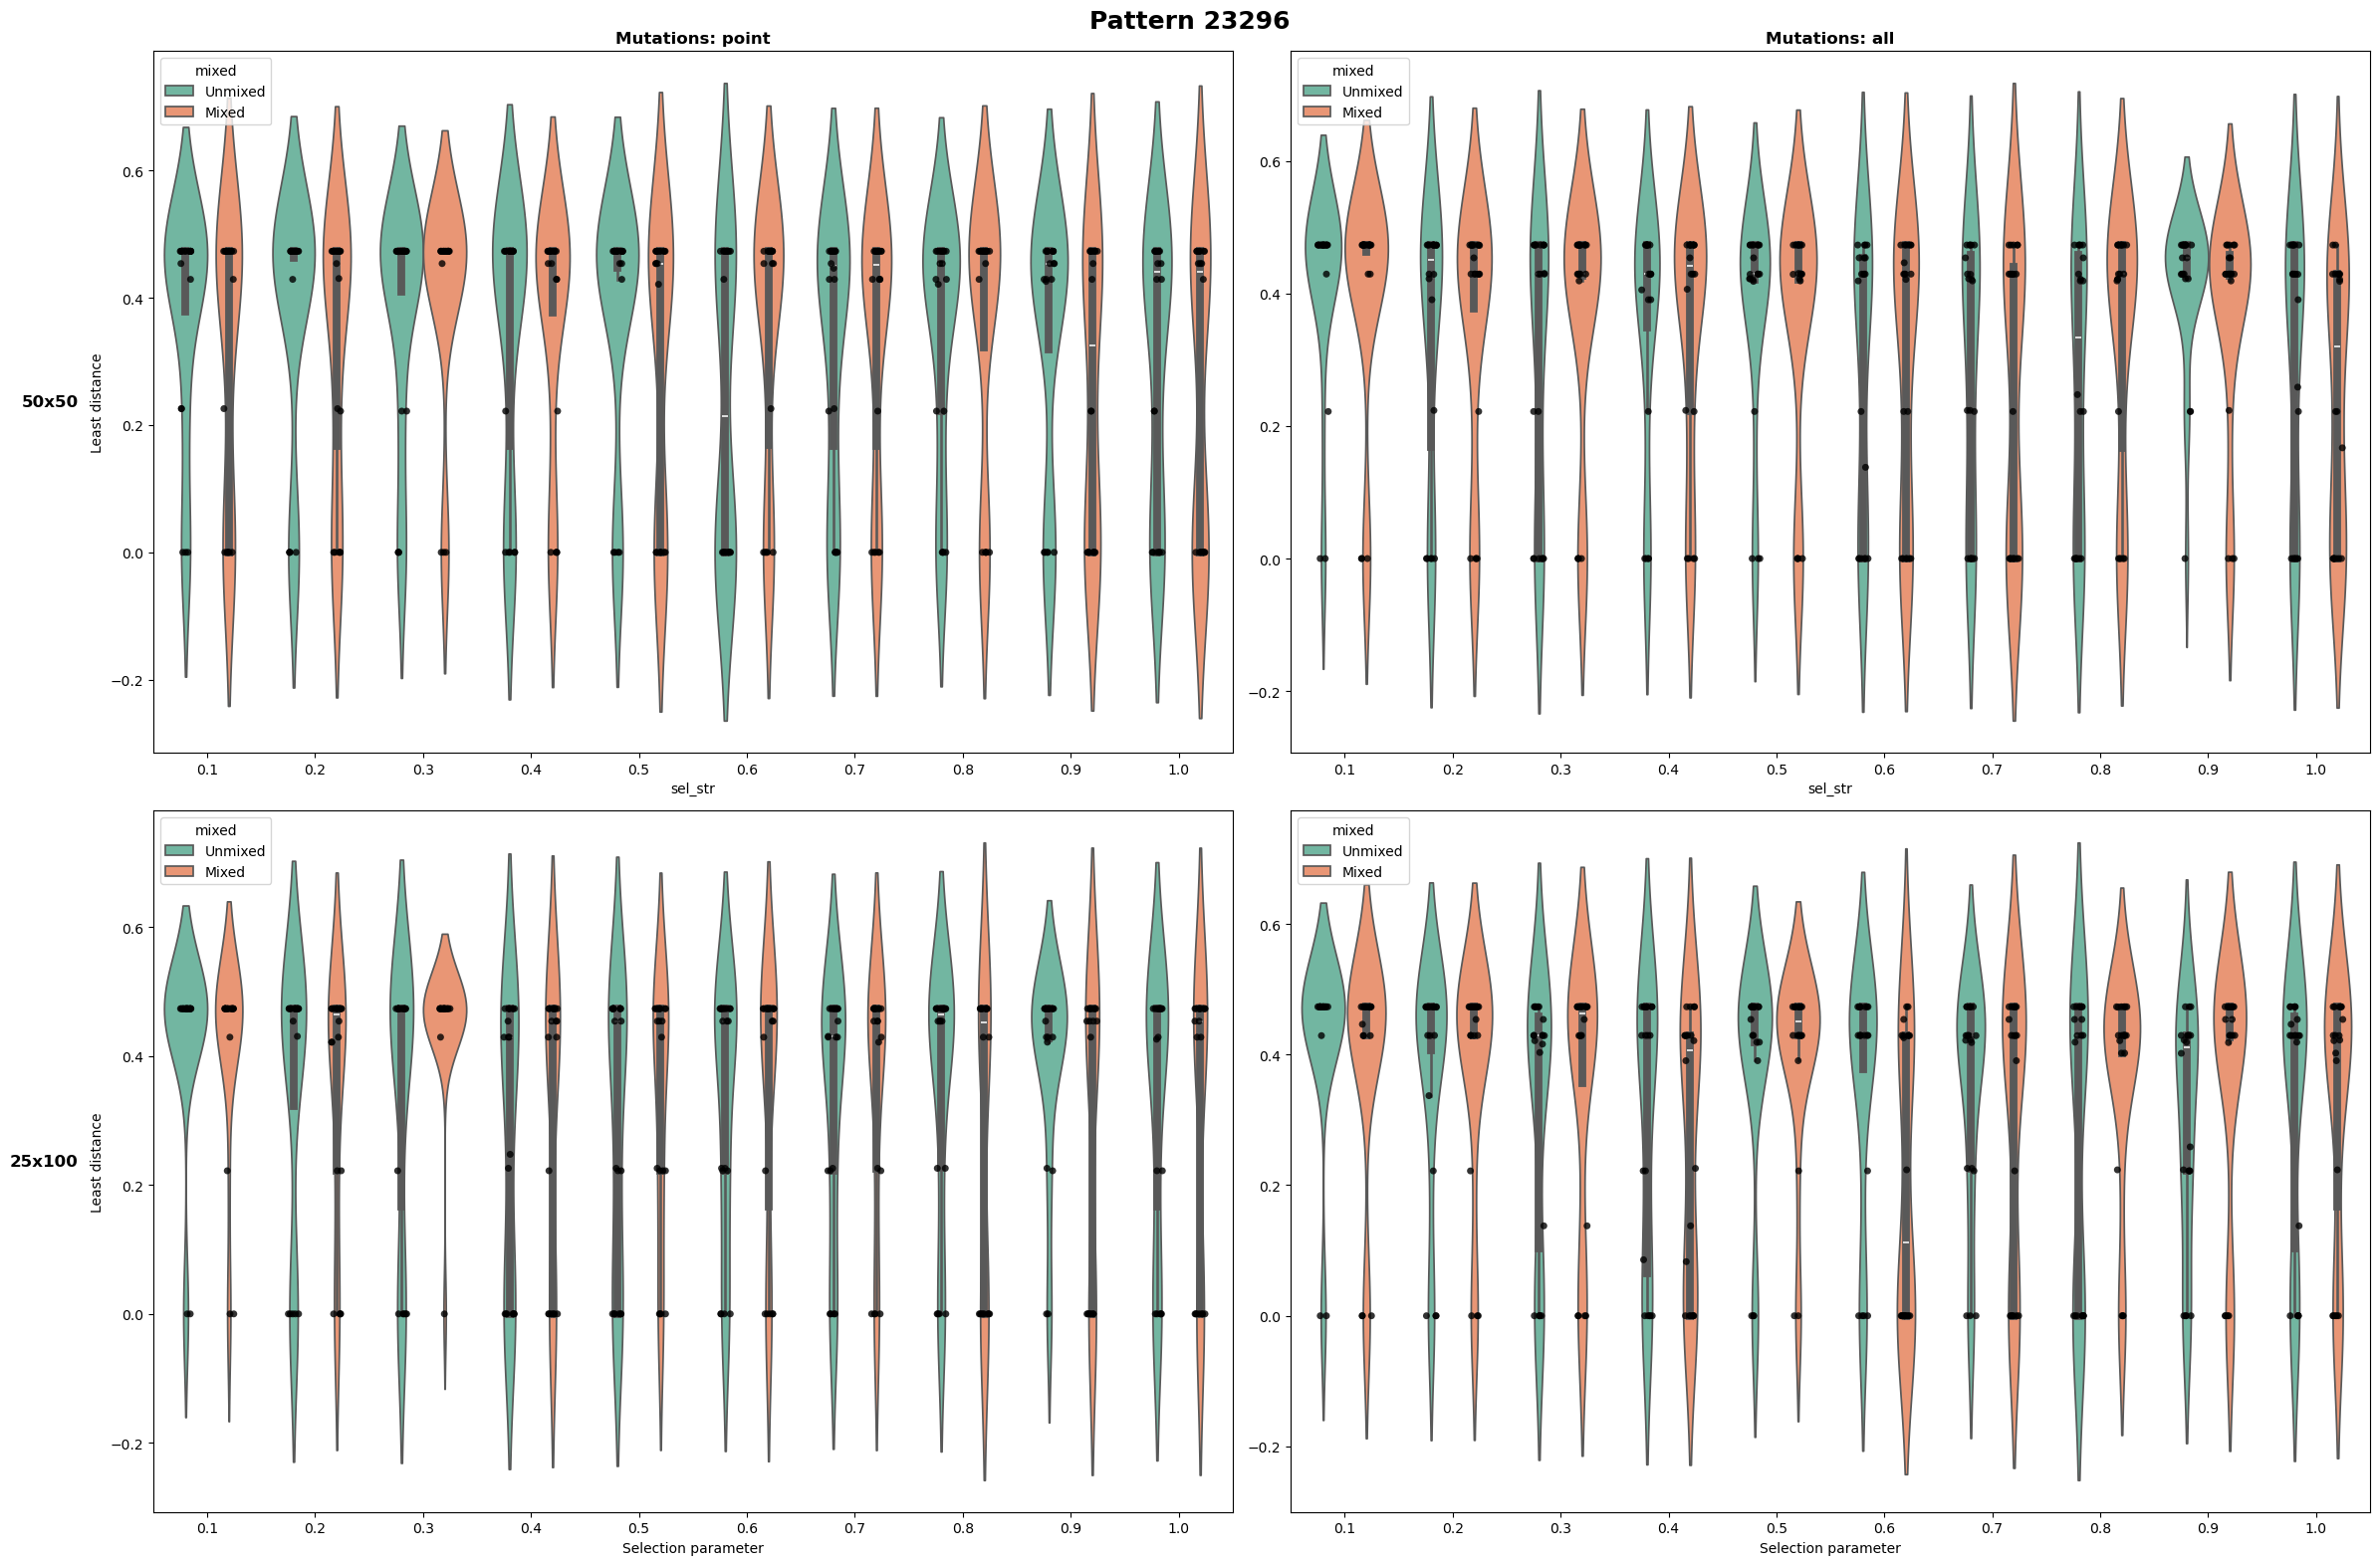

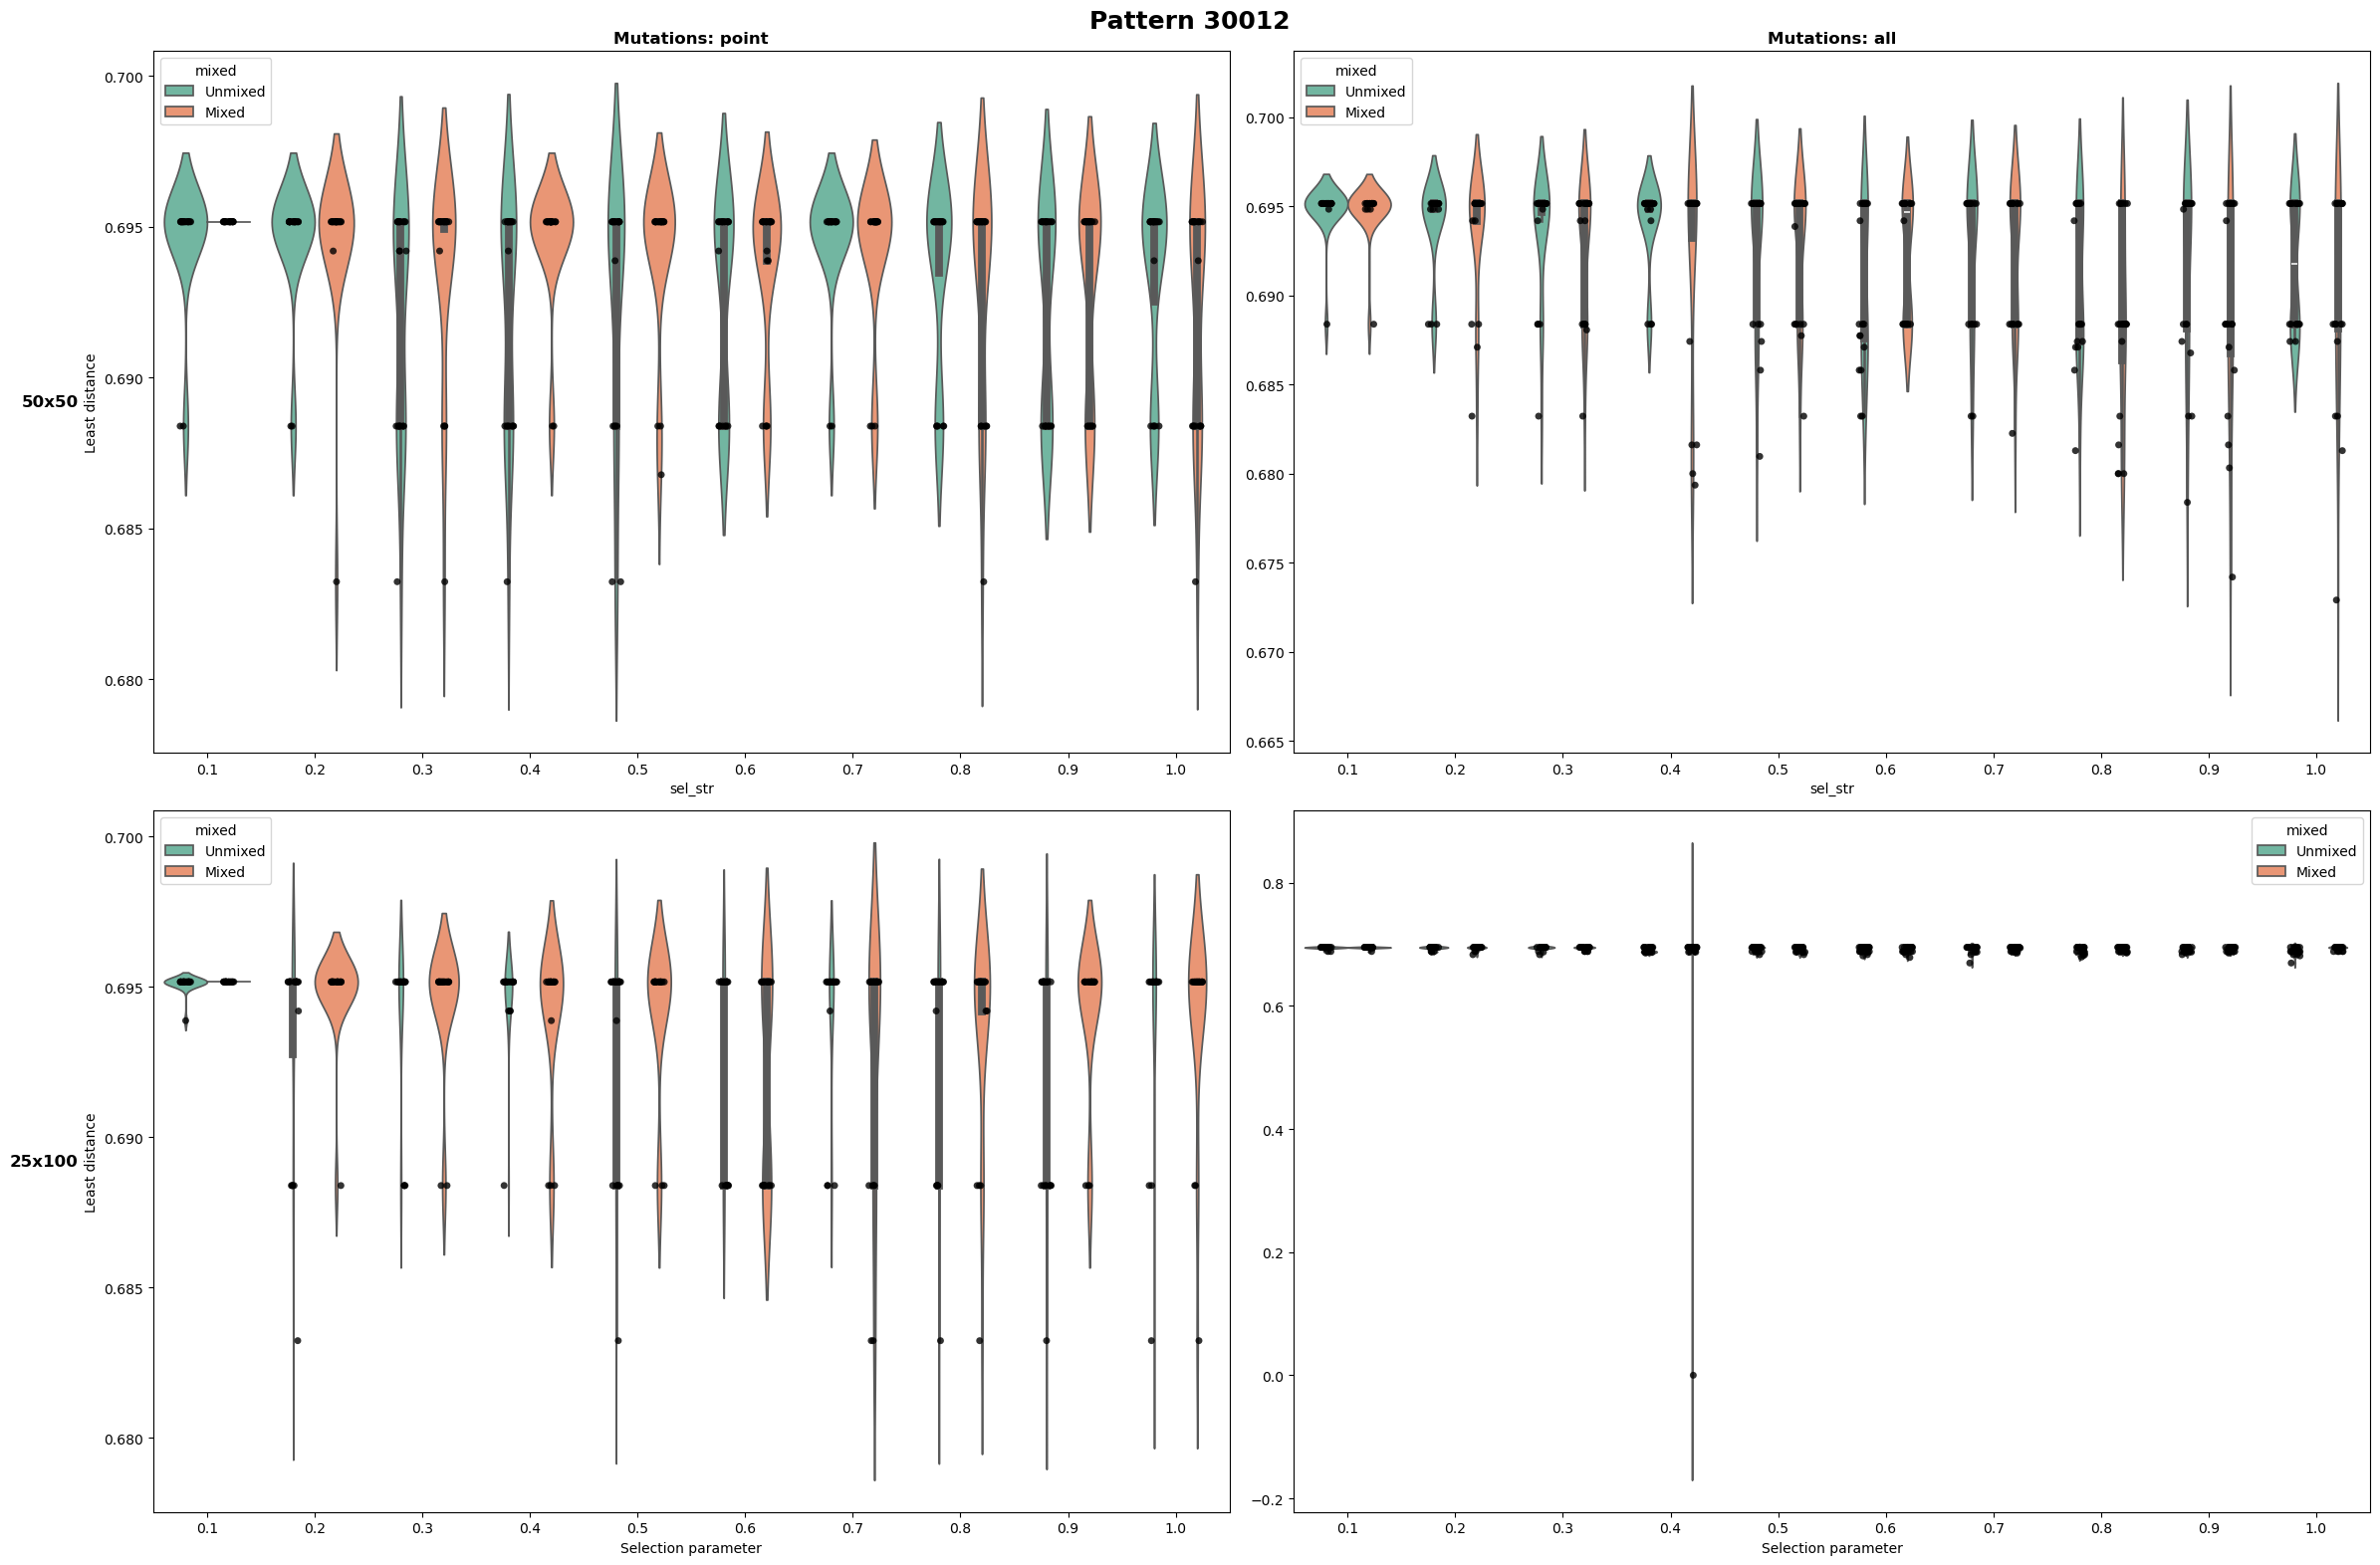

In [16]:
for p in patterns:
    fig, axes = plt.subplots(2, 2, figsize=(24,16))

    for i, df in enumerate([data_eleventh[data_eleventh["target"] == p], data_tenth[data_tenth["target"] == p]]):
        for j, mut in enumerate(["point", "all"]):
            simple_plotter_violin(axis = axes[i][j],
                                  data = df[df["mutations"] == mut],
                                  x="sel_str",
                                  y="least_distance")
            axes[0][j].set_title("Mutations: " + mut, fontweight="bold")
            axes[1][j].set_xlabel("Selection parameter")
        axes[i][0].set_ylabel("Least distance")
        axes[i][1].set_ylabel("")
        axes[i][0].annotate(list(df["gridsize"])[0], 
                            xy=(0, 0.5), xycoords="axes fraction",
                            xytext=(-ax.yaxis.labelpad - 50, 0),
                            textcoords="offset points",
                            ha="right", va="center",
                            fontsize=12, fontweight="bold")
    fig.suptitle("Pattern " + p, fontsize=18, fontweight="bold")
    fig.tight_layout()
    plt.savefig(savedir + "grid_comparisons_p" + p + "_t100k_ss0.1-1_10xlower_point_rates.png")
            